# Education Project Template

**Author:** Alyssa Zukas

**Date:** October 29, 2025


**Objective:** This project addresses inequality of educational opportunity in U.S. high schools. Here we will focus on analyzing the relationship between the average student performance on the ACT or SAT exams that students take as part of the college application process.


## Domain Problem 

**Problem Statement:** Does school geoassignment have a strong effect on school performance?
 
In order to do answer this question, we will be analyzing the relationship between a student bodies average ACT (and their equivalent SAT) scores and the schools locale classification (city, suburban, town, rural).

We expect to see a range of ACT/SAT exam scores, but to accuratly answer our question, we will also be analyzing the relationship of exam scores against five other socioeconomic factors - unemployment rate, percentage of adults with a college degree, percentage of children in a married couple family, median household income, and percentage of students at the school that are eligible for free or reduced price lunch. 

Althought our problem statement focuses on one socioeconomic factor, we want to incorporate other factors into our analysis so that we can better understand the level in which locale classification affects school performance. In other words, we want to compare the relationship of exam scores and each of these factors so we can determine if locale classification has a smaller or larger effect in comparison to the others.

## Analytic Approach 

In order to answer our original question, we will analyze the relationship of average ACT/SAT exam scores accross multiple socioeconomic variables. By having multiple relationships to compare across, we will hopefully be able to determine whether or not a schools geoassignment classification has an effect on school performance, in addition to **the level** in which this occurs. 

Based off of what we discover is our statistical analyses, we will use a **Diagnostic Approach** to test hypotheses and make inferences about the relationship between a schools geographical assignment and academic performance.

## Data Collection

### Data Sources

This project utilizes three data sets:
- <span style="color: red;">EdGap_data.xlsx</span>
- <span style="color: red;">ccd_sch_029_1617_w_1a_11212017.csv</span>
- <span style="color: red;">EDGE_GEOCODE_PUBLICSCH_1617.xlsx</span>


**EdGap:** The 1st primary data set is the EdGap_data.xlsx data set from **EdGap.org**. This includes the school ID in respect to the values (percentages, amounts, etc) for the ACT/SAT exam scores and the five socioeconomic variables outside of locale classification. This will be denoted as `edgap_info`.

**School Information:** The 2nd is a data set from the National Center for Education Statistics (NCES), displaying information about a large subset of schools. This includes the school ID, name, city, state, zip code, and several other characteristics of the school district in the year of 2016. This will be denoted as `school_info`.

**Geographical Information:** The 3rd data set is also from National Center for Education Statistics (NCES), displaying the `locale` in the year of 2016 for **public schools districts** (11,12,13, etc). This is the geoassignment for that school depending on the schools Longitute and Lattitude geographical information. These codes where then used to calaulte the percentage of students enrolled in each of these catargores- **City, Subarb, Town, or Rural**. <br>
These are already in the dataset labeled as columns that follow the format: `PCT_CITY11`...

- These locale classification assignments follow the value distribution standard found in the [EDGE Geocode Tech Doc](https://nces.ed.gov/programs/edge/docs/EDGE_GEOCODE_PUBLIC_TECHDOC.pdf)

#### EdGap Data

All socioeconomic data (household income, unemployment, adult educational attainment, and family structure) are from the **Census Bureau’s American Community Survey**.

- **EdGap.org** report that ACT and SAT score data is from each state’s department of education or some other public data release. The nature of the other public data release is not known, although the quality of the census data and the department of education data can be assumed to be reasonably high.

- **EdGap.org** do not indicate that they processed the data in any way. <br> 
The data were assembled by the EdGap.org team, so there is always the possibility for human error. Given the public nature of the data, we would be able to consult the original data sources to check the quality of the data if we had any questions.

#### School Information Data

The school information data from the **National Center for Education Statistics (NCES)** consists of basic identifying information about schools and can be assumed to be of **reasonably high quality**. 

As for the data from **EdGap.org data**, the school information data is public, so we would be able to consult the original data sources to check the quality of the data if we had any questions.

### Data Dictionary

**School Info**
- NCES SCH School ID: National Center for Education Statistics school identification number 
- NCES EDGE School Urbanicity: National Center for Education Statistics school urbanicity locale codes.

**Socioeconomic Factors**
- CT Unemployment Rate: Census tract unemployment rate
- CT Pct Adults with College Degree: Census tract percentage of adults with a college degree
<br>
- CT Pct Children In Married Couple Family: Census tract percentage of children in a married couple family.
- CT Median Household Income: Census tract median household income in dollars
- School Pct Free and Reduced Lunch: Percentage of students at the school eligible for free or reduced price lunch.
<br>
- **Newly added variables**:
    - `geoassignment`, which will represent the labels - City, Subarb, Town, or Rural - based off of the locale code.
    - `percent_city`, which will represent the percentage of enrolled students attending schools in a City (locale 11, 12, 13)
    - `percent_subarb`, which will represent the percentage of enrolled students attending schools in a Suburd (locale 21, 22, 23)
    - `percent_town`, which will represent the percentage of enrolled students attending schools in a Town (locale 31, 32, 33)
    - `percent_rural`, which will represent the percentage of enrolled students attending schools in a Rural area (locale 41, 42, 43)
      
**ACT and SAT Exam Scores**
- School ACT average (or equivalent if SAT score): Average ACT score for the school. If the average SAT score is reported by the school, it is converted to an equivalent ACT scoreLinks to an external site.. Scores range from 1 to 36, with 36 being the highest score.
<br>
<br>
Note that the attendance area for a school may contain multiple census tracts.

## Data Processing 

### Import Libraries & Loading the data

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import seaborn - a data visualization library built on matplotlib
import seaborn as sns
# set the plotting style
sns.set_style("whitegrid")

# Set the plotting style
sns.set_style("whitegrid")

**Load each dataset individually so we can easily isolate any errors in the process:**

EdGap Information

In [2]:
# Load the EdGap 
edgap_info = pd.read_excel(
    "/Users/alyssa.zukas/data5100/education/data/EdGap_data.xlsx",
    dtype={'NCESSCH School ID': object}
)

/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


^ Notice an error above, this will not affect the output. <br>
This will read in the EdGap data from a raw data file downloaded in our data folder for this project.

School Information

In [3]:
!wget -O ccd_sch_029_1617_w_1a_11212017.csv "https://www.dropbox.com/s/lkl5nvcdmwyoban/ccd_sch_029_1617_w_1a_11212017.csv?dl=1"


--2025-10-30 15:50:53--  https://www.dropbox.com/s/lkl5nvcdmwyoban/ccd_sch_029_1617_w_1a_11212017.csv?dl=1
162.125.1.18w.dropbox.com (www.dropbox.com)... 2620:100:6016:18::a27d:112, 
Connecting to www.dropbox.com (www.dropbox.com)|2620:100:6016:18::a27d:112|:443... connected.
302 Foundest sent, awaiting response... 
Location: https://www.dropbox.com/scl/fi/o8wf1f534pb4u7uavgjxm/ccd_sch_029_1617_w_1a_11212017.csv?rlkey=k2aey38xie2vz9ge4a0v3rrib&dl=1 [following]
--2025-10-30 15:50:53--  https://www.dropbox.com/scl/fi/o8wf1f534pb4u7uavgjxm/ccd_sch_029_1617_w_1a_11212017.csv?rlkey=k2aey38xie2vz9ge4a0v3rrib&dl=1
Reusing existing connection to [www.dropbox.com]:443.
302 Foundest sent, awaiting response... 
Location: https://uc8d9016a0d6af5621bb6975f4f3.dl.dropboxusercontent.com/cd/0/inline/C0N2huYjEbezYNSI0KMoWPbx3pBmngFDbOUIHMPxmeyLn3CVOCDNIjGHrY1aNxggVfAeEAdkwLIC8-MqxcSQFSRjibzvtXu3Q8WKJtY-J-8mvjfss1FynSw28WbUDlkOGdQ/file?dl=1# [following]
--2025-10-30 15:50:54--  https://uc8d9016a0d6af562

In [4]:
!ls

ccd_sch_029_1617_w_1a_11212017.csv education_resubmission.ipynb
education_clean.csv                education_template.ipynb
education_final.ipynb


In [5]:
# Load in the School Information data
school_info = pd.read_csv(
    "ccd_sch_029_1617_w_1a_11212017.csv", encoding="unicode_escape"
)

/var/folders/z2/g11yqhsj1k71fwt1tzjpqgp80000gn/T/ipykernel_63788/1336598721.py:2: DtypeWarning: Columns (6,9,14,15,18,19,21,22,25,26,29,31,35,39,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  school_info = pd.read_csv(


^^ This error above is pandas telling us that there are mis-matching data types in this dataset.<br>
This error is harmless for now, and we can change the datatypes and formatting to all match later on.

Geographical Information

In [6]:
# Read in the Geographical Info excel file
geo_info = pd.read_excel(
    "/Users/alyssa.zukas/data5100/education/data/EDGE_GEOCODE_PUBLICSCH_1617.xlsx",
    dtype={'NCESEDGE School Urbanicity': object} 
)

### Exploring Contents of the data

#### Sizes 
head, tail, shape

**First start by looking at the `head` and `tail` of each data set:**

In [7]:
edgap_info

,NCESSCH School ID,CT Unemployment Rate,CT Pct Adults with College Degree,CT Pct Childre In Married Couple Family,CT Median Household Income,School ACT average (or equivalent if SAT score),School Pct Free and Reduced Lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641
...,...,...,...,...,...,...,...
7981,560530200294,0.034549,0.590780,0.720077,64891.0,18.500000,0.232156
7982,560569000311,0.069538,0.633860,0.808841,44603.0,22.300000,0.083871
7983,560569500360,0.035159,0.764566,0.776570,44896.0,21.500000,0.184829
7984,560576200324,0.063877,0.670532,0.879324,92134.0,19.700000,0.112583


In [8]:
school_info

,SCHOOL_YEAR,FIPST,STATENAME,ST,SCH_NAME,LEA_NAME,STATE_AGENCY_NO,UNION,ST_LEAID,LEAID,...,G_10_OFFERED,G_11_OFFERED,G_12_OFFERED,G_13_OFFERED,G_UG_OFFERED,G_AE_OFFERED,GSLO,GSHI,LEVEL,IGOFFERED
0,2016-2017,1,ALABAMA,AL,Sequoyah Sch - Chalkville Campus,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
1,2016-2017,1,ALABAMA,AL,Camps,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
2,2016-2017,1,ALABAMA,AL,Det Ctr,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
3,2016-2017,1,ALABAMA,AL,Wallace Sch - Mt Meigs Campus,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
4,2016-2017,1,ALABAMA,AL,McNeel Sch - Vacca Campus,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102178,2016-2017,78,U.S. VIRGIN ISLANDS,VI,GLADYS A. ABRAHAM ELEMENTARY SCHOOL,Saint Thomas - Saint John School District,1,NaN,VI-001,7800030,...,No,No,No,No,No,No,KG,06,Elementary,As reported
102179,2016-2017,78,U.S. VIRGIN ISLANDS,VI,ULLA F MULLER ELEMENTARY SCHOOL,Saint Thomas - Saint John School District,1,NaN,VI-001,7800030,...,No,No,No,No,No,No,KG,06,Elementary,As reported
102180,2016-2017,78,U.S. VIRGIN ISLANDS,VI,YVONNE BOWSKY ELEMENTARY SCHOOL,Saint Thomas - Saint John School District,1,NaN,VI-001,7800030,...,No,No,No,No,No,No,KG,06,Elementary,As reported
102181,2016-2017,78,U.S. VIRGIN ISLANDS,VI,CANCRYN JUNIOR HIGH SCHOOL,Saint Thomas - Saint John School District,1,NaN,VI-001,7800030,...,No,No,No,No,No,No,07,08,Middle,As reported


In [9]:
geo_info

,NCESSCH,NAME,OPSTFIPS,STREET,CITY,STATE,ZIP,STFIP,CNTY,NMCNTY,...,NMCBSA,CBSATYPE,CSA,NMCSA,NECTA,NMNECTA,CD,SLDL,SLDU,SURVYEAR
0,10000200277,Sequoyah Sch - Chalkville Campus,1,1000 Industrial School Road,Birmingham,AL,35220,01,01073,Jefferson County,...,"Birmingham-Hoover, AL",1,142,"Birmingham-Hoover-Talladega, AL",N,N,0106,01044,01020,2016
1,10000201667,Camps,1,1601 County Rd. 57,Prattville,AL,36067,01,01001,Autauga County,...,"Montgomery, AL",1,N,N,N,N,0102,01042,01030,2016
2,10000201670,Det Ctr,1,2109 Bashi Rd Bldg 509,Thomasville,AL,36784,01,01025,Clarke County,...,N,0,N,N,N,N,0107,01068,01024,2016
3,10000201705,Wallace Sch - Mt Meigs Campus,1,1000 Industrial School Road,Mount Meigs,AL,36057,01,01101,Montgomery County,...,"Montgomery, AL",1,N,N,N,N,0103,01075,01025,2016
4,10000201706,McNeel Sch - Vacca Campus,1,8950 Roebuck Blvd,Birmingham,AL,35206,01,01073,Jefferson County,...,"Birmingham-Hoover, AL",1,142,"Birmingham-Hoover-Talladega, AL",N,N,0107,01058,01020,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102168,780003000025,GLADYS A. ABRAHAM ELEMENTARY SCHOOL,78,68A ESTATE LINDBERG,Saint Thomas,VI,802,78,78030,St. Thomas Island,...,N,0,N,N,N,N,7898,N,N,2016
102169,780003000026,ULLA F MULLER ELEMENTARY SCHOOL,78,7B ESTATE CONTANT,Saint Thomas,VI,802,78,78030,St. Thomas Island,...,N,0,N,N,N,N,7898,N,N,2016
102170,780003000027,YVONNE BOWSKY ELEMENTARY SCHOOL,78,15B and 16 ESTATE MANDAHL,Saint Thomas,VI,802,78,78030,St. Thomas Island,...,N,0,N,N,N,N,7898,N,N,2016
102171,780003000033,CANCRYN JUNIOR HIGH SCHOOL,78,1 CROWN BAY,Saint Thomas,VI,804,78,78030,St. Thomas Island,...,N,0,N,N,N,N,7898,N,N,2016


**Now look at the size of each data set using the `shape()` attirubute:**

In [10]:
print(edgap_info.shape)

(7986, 7)


In [11]:
print(school_info.shape)

(102183, 65)


In [12]:
print(geo_info.shape)

(102173, 24)


**Oberservations:** We can see from the code above that:
- The EdGap Information dataset - <span style="color: red;">EdGap_data.xlsx</span> - has **7 variables** and **7986 entries**. Organized by the `NCESSCH School ID`.
- The School Information dataset - <span style="color: red;">ccd_sch_029_1617_w_1a_11212017.csv</span> - has **65 variables** and **102,181 entries**. Organized by the `SCHOOL_YEAR`.
- The Geographical Information dataset - <span style="color: red;">EDGE_GEOCODE_PUBLICSCH_1617.xlsx</span> - has **24 columns** and **102,173 entries**. Organized by the `NCESSCH` School ID.

#### Info()
Size, data types, and missing values.

We want to use the `info()` method to check the overall size of the data frame, and amount of missing values, and the data types of all current variables. 

In [13]:
edgap_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   NCESSCH School ID                                7986 non-null   object 
 1   CT Unemployment Rate                             7972 non-null   float64
 2   CT Pct Adults with College Degree                7973 non-null   float64
 3   CT Pct Childre In Married Couple Family          7961 non-null   float64
 4   CT Median Household Income                       7966 non-null   float64
 5   School ACT average (or equivalent if SAT score)  7986 non-null   float64
 6   School Pct Free and Reduced Lunch                7986 non-null   float64
dtypes: float64(6), object(1)
memory usage: 436.9+ KB


We can see here that for the **EdGap Information**, there are 7986 entries (as we already knew) so when we look at the `Non-Null Count` section for each vairable, we can see which ones having missing values - These will be the variables that have a non-null count **less than 7986**. 


**So the variables with missing values are**: Unemployment Rate, % of Adults with college degrees, % of Children with married parents, and Median Household Income .... That is 5 vairables out of the 6 total (not inlcuding hte School ID).

In [14]:
school_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 65 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   SCHOOL_YEAR          102183 non-null  object 
 1   FIPST                102183 non-null  int64  
 2   STATENAME            102183 non-null  object 
 3   ST                   102183 non-null  object 
 4   SCH_NAME             102183 non-null  object 
 5   LEA_NAME             102183 non-null  object 
 6   STATE_AGENCY_NO      102183 non-null  object 
 7   UNION                2533 non-null    float64
 8   ST_LEAID             102183 non-null  object 
 9   LEAID                102183 non-null  object 
 10  ST_SCHID             102183 non-null  object 
 11  NCESSCH              102181 non-null  float64
 12  SCHID                102181 non-null  float64
 13  MSTREET1             102181 non-null  object 
 14  MSTREET2             1825 non-null    object 
 15  MSTREET3         

We can see here that the School Information dataset has a total of **102,181** entries, so any variables with missing values will have a `Non-Null Count` value **less than 102181**. In this data set there are **are missing values**.

In [15]:
geo_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102173 entries, 0 to 102172
Data columns (total 24 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   NCESSCH   102173 non-null  int64  
 1   NAME      102173 non-null  object 
 2   OPSTFIPS  102173 non-null  int64  
 3   STREET    102173 non-null  object 
 4   CITY      102173 non-null  object 
 5   STATE     102173 non-null  object 
 6   ZIP       102173 non-null  int64  
 7   STFIP     102173 non-null  object 
 8   CNTY      102173 non-null  object 
 9   NMCNTY    102173 non-null  object 
 10  LOCALE    102173 non-null  object 
 11  LAT       102173 non-null  float64
 12  LON       102173 non-null  float64
 13  CBSA      102173 non-null  object 
 14  NMCBSA    102173 non-null  object 
 15  CBSATYPE  102173 non-null  int64  
 16  CSA       102173 non-null  object 
 17  NMCSA     102173 non-null  object 
 18  NECTA     102173 non-null  object 
 19  NMNECTA   102173 non-null  object 
 20  CD  

We can see that there are **no missing values** in any of the variables for the Geographical Information data.

#### Missing Values

**Let's count how many missing values there are in each data set:**

In [16]:
edgap_info.isna().sum()

NCESSCH School ID                                   0
CT Unemployment Rate                               14
CT Pct Adults with College Degree                  13
CT Pct Childre In Married Couple Family            25
CT Median Household Income                         20
School ACT average (or equivalent if SAT score)     0
School Pct Free and Reduced Lunch                   0
dtype: int64

We can see here that the **EdGap Information** data set has the following amount of missing values for each variable:

- **Unemployment Rate:** 14
- **% of Adults with college degrees:** 13
- **% of Children In Married Couple Families:** 25
- **Mediam Household Income:** 20


In [17]:
school_info.isna().sum()

SCHOOL_YEAR     0
FIPST           0
STATENAME       0
ST              0
SCH_NAME        0
               ..
G_AE_OFFERED    4
GSLO            4
GSHI            4
LEVEL           4
IGOFFERED       4
Length: 65, dtype: int64

We can get a better glimpse at how many values are missing in each of the variables for the School Information data. <br>
But since there are so many variables to account for, we will not worry about counting like we did in the EdGap dataset.

In [18]:
geo_info.isna().sum()

NCESSCH     0
NAME        0
OPSTFIPS    0
STREET      0
CITY        0
STATE       0
ZIP         0
STFIP       0
CNTY        0
NMCNTY      0
LOCALE      0
LAT         0
LON         0
CBSA        0
NMCBSA      0
CBSATYPE    0
CSA         0
NMCSA       0
NECTA       0
NMNECTA     0
CD          0
SLDL        0
SLDU        0
SURVYEAR    0
dtype: int64

In the above code we just wanted to verify that there are no missing values in the Geographical Information data.

#### Individual Columns 
.columns, unique()

In the following code we will use the `.columns` attribute to output all the columns in the data set, and the `.unique()` attribute to output an array of all entries in a specific columns (leaving out duplicates).

We will use these to analyze the Schoool Information and Geographical Information data sets, and determing which variable we will merge them on later.

1) Analyze the **Geographical Information:**

In [19]:
geo_info.columns

Index(['NCESSCH', 'NAME', 'OPSTFIPS', 'STREET', 'CITY', 'STATE', 'ZIP',
       'STFIP', 'CNTY', 'NMCNTY', 'LOCALE', 'LAT', 'LON', 'CBSA', 'NMCBSA',
       'CBSATYPE', 'CSA', 'NMCSA', 'NECTA', 'NMNECTA', 'CD', 'SLDL', 'SLDU',
       'SURVYEAR'],
      dtype='object')

<br>

**.... Wondering what each of these columns represent???**

In [20]:
geo_info['NCESSCH'].unique()

array([ 10000200277,  10000201667,  10000201670, ..., 780003000027,
       780003000033, 780003000034])

^ `NCESSCH` is the school ID

In [21]:
geo_info['STATE'].unique()

array(['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'MD', 'FL',
       'GA', 'HI', 'ID', 'OR', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME',
       'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM',
       'NY', 'NC', 'ND', 'OH', 'OK', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
       'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY', 'AS', 'AP', 'AE', 'PR',
       'GU', 'VI'], dtype=object)

^ `STATE` is the state label

In [22]:
geo_info['NAME'].unique()

array(['Sequoyah Sch - Chalkville Campus', 'Camps', 'Det Ctr', ...,
       'YVONNE BOWSKY ELEMENTARY SCHOOL', 'CANCRYN JUNIOR HIGH SCHOOL',
       'BERTHA BOSCHULTE JUNIOR HIGH'], dtype=object)

^ `NAME` is the school name

In [23]:
geo_info['CNTY'].unique()

array(['01073', '01001', '01025', ..., '78010', '78030', '78020'],
      dtype=object)

^ `CNTY` is the county

In [24]:
geo_info['NMCNTY'].unique()

array(['Jefferson County', 'Autauga County', 'Clarke County', ...,
       'St. Croix Island', 'St. Thomas Island', 'St. John Island'],
      dtype=object)

^ `NMCNTY` is the county name 

In [25]:
geo_info['LOCALE'].unique()

array(['21', '41', '12', '32', '42', '13', '31', '33', '23', '43', '22',
       '11', 'N'], dtype=object)

^ `LOCALE` is the geocode label which will be used to identify the georaphical setting of the school. 

**Observation:** The above output shows us that our initial variable of interest, `LOCALE`, will actually NOT output the direct value we are trying to find - which is: **City, Suburban, Town, Rural** - This means that we will eventually have to create a new dataset assigning these integers to one of the 4 geographical labels.

2) Analyze the **School Information** dataset:

In [26]:
school_info.columns

Index(['SCHOOL_YEAR', 'FIPST', 'STATENAME', 'ST', 'SCH_NAME', 'LEA_NAME',
       'STATE_AGENCY_NO', 'UNION', 'ST_LEAID', 'LEAID', 'ST_SCHID', 'NCESSCH',
       'SCHID', 'MSTREET1', 'MSTREET2', 'MSTREET3', 'MCITY', 'MSTATE', 'MZIP',
       'MZIP4', 'LSTREET1', 'LSTREET2', 'LSTREET3', 'LCITY', 'LSTATE', 'LZIP',
       'LZIP4', 'PHONE', 'WEBSITE', 'SY_STATUS', 'SY_STATUS_TEXT',
       'UPDATED_STATUS', 'UPDATED_STATUS_TEXT', 'EFFECTIVE_DATE',
       'SCH_TYPE_TEXT', 'SCH_TYPE', 'RECON_STATUS', 'OUT_OF_STATE_FLAG',
       'CHARTER_TEXT', 'CHARTAUTH1', 'CHARTAUTHN1', 'CHARTAUTH2',
       'CHARTAUTHN2', 'NOGRADES', 'G_PK_OFFERED', 'G_KG_OFFERED',
       'G_1_OFFERED', 'G_2_OFFERED', 'G_3_OFFERED', 'G_4_OFFERED',
       'G_5_OFFERED', 'G_6_OFFERED', 'G_7_OFFERED', 'G_8_OFFERED',
       'G_9_OFFERED', 'G_10_OFFERED', 'G_11_OFFERED', 'G_12_OFFERED',
       'G_13_OFFERED', 'G_UG_OFFERED', 'G_AE_OFFERED', 'GSLO', 'GSHI', 'LEVEL',
       'IGOFFERED'],
      dtype='object')

<br>

**.... Wondering what each of these columns represent???**

In [27]:
school_info['LSTATE'].unique()

array(['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'MD', 'FL',
       'GA', 'HI', 'ID', 'OR', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME',
       'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM',
       'NY', 'NC', 'ND', 'OH', 'OK', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
       'UT', 'VT', 'VA', 'No', 'Yes', 'WA', 'WV', 'WI', 'WY', 'AS', 'AP',
       'AE', 'PR', 'GU', 'VI'], dtype=object)

^ `LSTATE` is the state lettering

In [28]:
school_info['ST'].unique()

array(['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA',
       'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA',
       'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY',
       'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
       'UT', 'VT', 'VA', '1', 'WA', 'WV', 'WI', 'WY', 'BI', 'AS', 'DA',
       'GU', 'PR', 'VI'], dtype=object)

^ `ST` is the state abbraviation. 

In [29]:
school_info['STATENAME'].unique()

array(['ALABAMA', 'ALASKA', 'ARIZONA', 'ARKANSAS', 'CALIFORNIA',
       'COLORADO', 'CONNECTICUT', 'DELAWARE', 'DISTRICT OF COLUMBIA',
       'FLORIDA', 'GEORGIA', 'HAWAII', 'IDAHO', 'ILLINOIS', 'INDIANA',
       'IOWA', 'KANSAS', 'KENTUCKY', 'LOUISIANA', 'MAINE', 'MARYLAND',
       'MASSACHUSETTS', 'MICHIGAN', 'MINNESOTA', 'MISSISSIPPI',
       'MISSOURI', 'MONTANA', 'NEBRASKA', 'NEVADA', 'NEW HAMPSHIRE',
       'NEW JERSEY', 'NEW MEXICO', 'NEW YORK', 'NORTH CAROLINA',
       'NORTH DAKOTA', 'OHIO', 'OKLAHOMA', 'OREGON', 'PENNSYLVANIA',
       'RHODE ISLAND', 'SOUTH CAROLINA', 'SOUTH DAKOTA', 'TENNESSEE',
       'TEXAS', 'UTAH', 'VERMONT', 'VIRGINIA', 'Open', 'WASHINGTON',
       'WEST VIRGINIA', 'WISCONSIN', 'WYOMING',
       'BUREAU OF INDIAN EDUCATION', 'AMERICAN SAMOA',
       'DEPARTMENT OF DEFENSE EDUCATION ACTIVITY', 'GUAM', 'PUERTO RICO',
       'U.S. VIRGIN ISLANDS'], dtype=object)

^ `STATENAME` is the full state name

In [30]:
school_info['SCH_NAME'].unique()

array(['Sequoyah Sch - Chalkville Campus', 'Camps', 'Det Ctr', ...,
       'YVONNE BOWSKY ELEMENTARY SCHOOL', 'CANCRYN JUNIOR HIGH SCHOOL',
       'BERTHA BOSCHULTE JUNIOR HIGH'], dtype=object)

`SCH_NAME` is the school name

**Oberservation:** It is hard to know what the lettering in the original column naming conventions are referring to, but these outputs above help us better understand what each column is representing. For example, I can see here that `NAME` is referring to the school name, and we may want to use this later.

<br>

**Determine which columns in each data set will be used to identify the School ID** <br>

Now that we have a better idea of what values each of the columns contain, we want to decide which of these variables will be used as out `key indicator` to merge on. <br>
We know that we want to merge on the **School ID**, but there are many variables that reference to an ID number.. so which one should we use in each?

In [31]:
edgap_info.columns

Index(['NCESSCH School ID', 'CT Unemployment Rate',
       'CT Pct Adults with College Degree',
       'CT Pct Childre In Married Couple Family', 'CT Median Household Income',
       'School ACT average (or equivalent if SAT score)',
       'School Pct Free and Reduced Lunch'],
      dtype='object')

In [32]:
edgap_info['NCESSCH School ID'].unique()

array([100001600143, 100008000024, 100008000225, ..., 560569500360,
       560576200324, 560583000335], dtype=object)

^ For the **edgap_info** data set... we will merge on `NCESSCH School ID`

In [33]:
geo_info.columns

Index(['NCESSCH', 'NAME', 'OPSTFIPS', 'STREET', 'CITY', 'STATE', 'ZIP',
       'STFIP', 'CNTY', 'NMCNTY', 'LOCALE', 'LAT', 'LON', 'CBSA', 'NMCBSA',
       'CBSATYPE', 'CSA', 'NMCSA', 'NECTA', 'NMNECTA', 'CD', 'SLDL', 'SLDU',
       'SURVYEAR'],
      dtype='object')

In [34]:
geo_info['NCESSCH'].unique()

array([ 10000200277,  10000201667,  10000201670, ..., 780003000027,
       780003000033, 780003000034])

^ For the **geo_info** data set, we will merge on the variable `NCESSCH`

In [35]:
school_info.columns

Index(['SCHOOL_YEAR', 'FIPST', 'STATENAME', 'ST', 'SCH_NAME', 'LEA_NAME',
       'STATE_AGENCY_NO', 'UNION', 'ST_LEAID', 'LEAID', 'ST_SCHID', 'NCESSCH',
       'SCHID', 'MSTREET1', 'MSTREET2', 'MSTREET3', 'MCITY', 'MSTATE', 'MZIP',
       'MZIP4', 'LSTREET1', 'LSTREET2', 'LSTREET3', 'LCITY', 'LSTATE', 'LZIP',
       'LZIP4', 'PHONE', 'WEBSITE', 'SY_STATUS', 'SY_STATUS_TEXT',
       'UPDATED_STATUS', 'UPDATED_STATUS_TEXT', 'EFFECTIVE_DATE',
       'SCH_TYPE_TEXT', 'SCH_TYPE', 'RECON_STATUS', 'OUT_OF_STATE_FLAG',
       'CHARTER_TEXT', 'CHARTAUTH1', 'CHARTAUTHN1', 'CHARTAUTH2',
       'CHARTAUTHN2', 'NOGRADES', 'G_PK_OFFERED', 'G_KG_OFFERED',
       'G_1_OFFERED', 'G_2_OFFERED', 'G_3_OFFERED', 'G_4_OFFERED',
       'G_5_OFFERED', 'G_6_OFFERED', 'G_7_OFFERED', 'G_8_OFFERED',
       'G_9_OFFERED', 'G_10_OFFERED', 'G_11_OFFERED', 'G_12_OFFERED',
       'G_13_OFFERED', 'G_UG_OFFERED', 'G_AE_OFFERED', 'GSLO', 'GSHI', 'LEVEL',
       'IGOFFERED'],
      dtype='object')

In [36]:
school_info['NCESSCH'].unique()

array([1.00002003e+10, 1.00002017e+10, 1.00002017e+10, ...,
       7.80003000e+11, 7.80003000e+11, 7.80003000e+11])

In [37]:
school_info['SCHID'].unique()

array([ 100277.,  101667.,  101670., ..., 7800027., 7800033., 7800034.])

^ For the **school_info** data set, we will merge on the `NCESSCH` variables.

#### Overall Summary!! 

Based off of the information above, we can assume the following: 

- The **EdGap Info** dataset includes the following variables:

    - NCESSCH School ID
    - Unemployment Rate
    - % of Adults with College Degree
    - % of Childre In Married Couple Family
    - Median Household Income
    - School ACT average (or equivalent if SAT score)
    - % of Free and Reduced Lunch
      <br>
      <br>

- The **School Information** and **Geographical Information** datasets are much larger than the **EdGap** data set.
 
- There are **missing values** in the EdGap and School Information datasets, but not the Geographical Information. <br>

- Each dataset is in either a tidy or long format.

- The variable (identifier) we want to merge the data sets on is the School ID! The **data type** of the variable that we will **merge on** for each data set is as follows:
    - EdGap dataset: `NCESSCH School ID` is an **object**
    - School Information dataset: `NCESSCH` school ID is a **float64**
    - Geographical Information dataset: `NCESSCH` is an **int64** <br>


### Initial Analysis - Should we Procede?

We want to perform some initial exploration on the relationship between variables before moving forward wiht further analysis. This is so we can save time and determine whether or not we thing the data we currently have will suffice in answering the original question. If not, we will stop here.

#### Pair Plot

Make a **PAIR PLOT** to explore the relationships between variables:

In [38]:
edgap_info.columns

Index(['NCESSCH School ID', 'CT Unemployment Rate',
       'CT Pct Adults with College Degree',
       'CT Pct Childre In Married Couple Family', 'CT Median Household Income',
       'School ACT average (or equivalent if SAT score)',
       'School Pct Free and Reduced Lunch'],
      dtype='object')

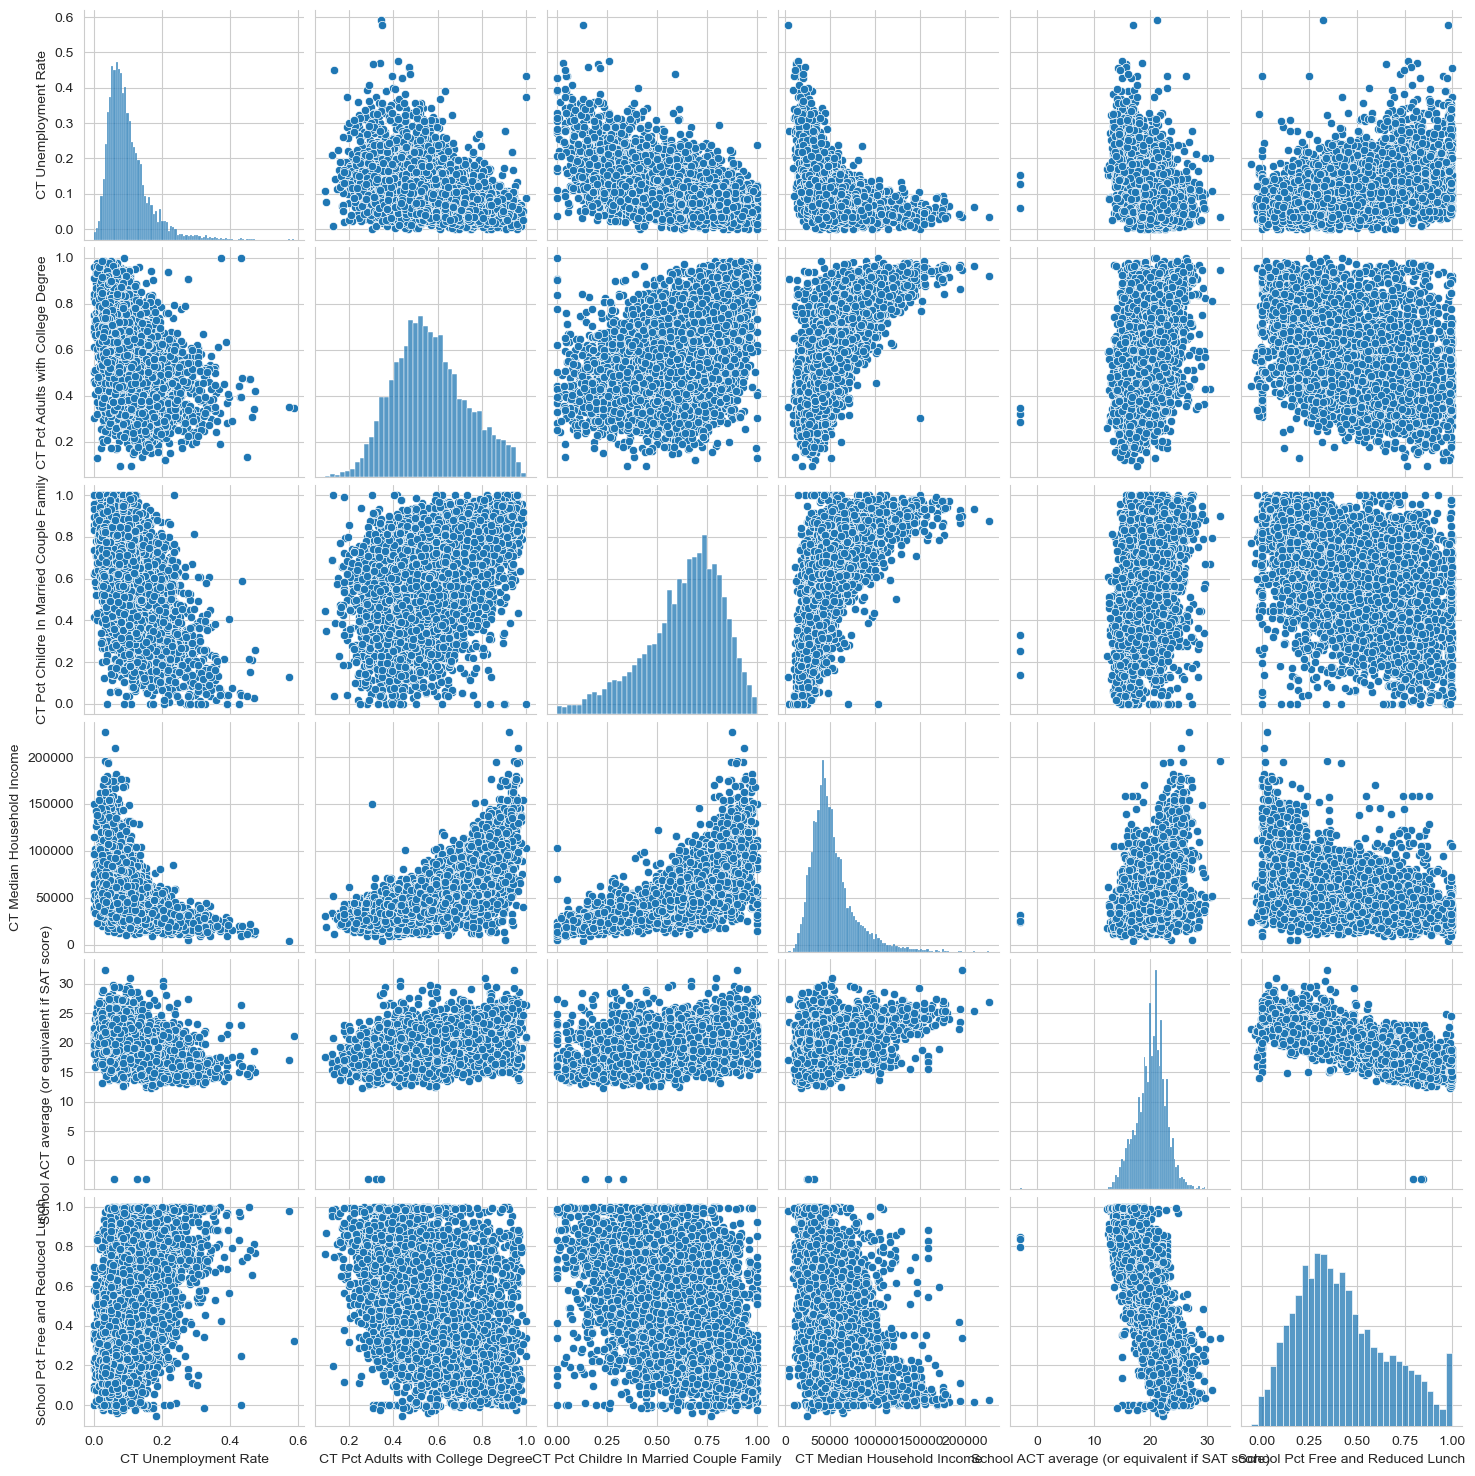

In [39]:
sns.pairplot(
    edgap_info.drop(columns="NCESSCH School ID")
);
plt.show()

^^ The above plots show us the relationship of each variable individually against eachother.

#### Regression Lines

Add **REGRESSION LINES** and **format** the pairplot:

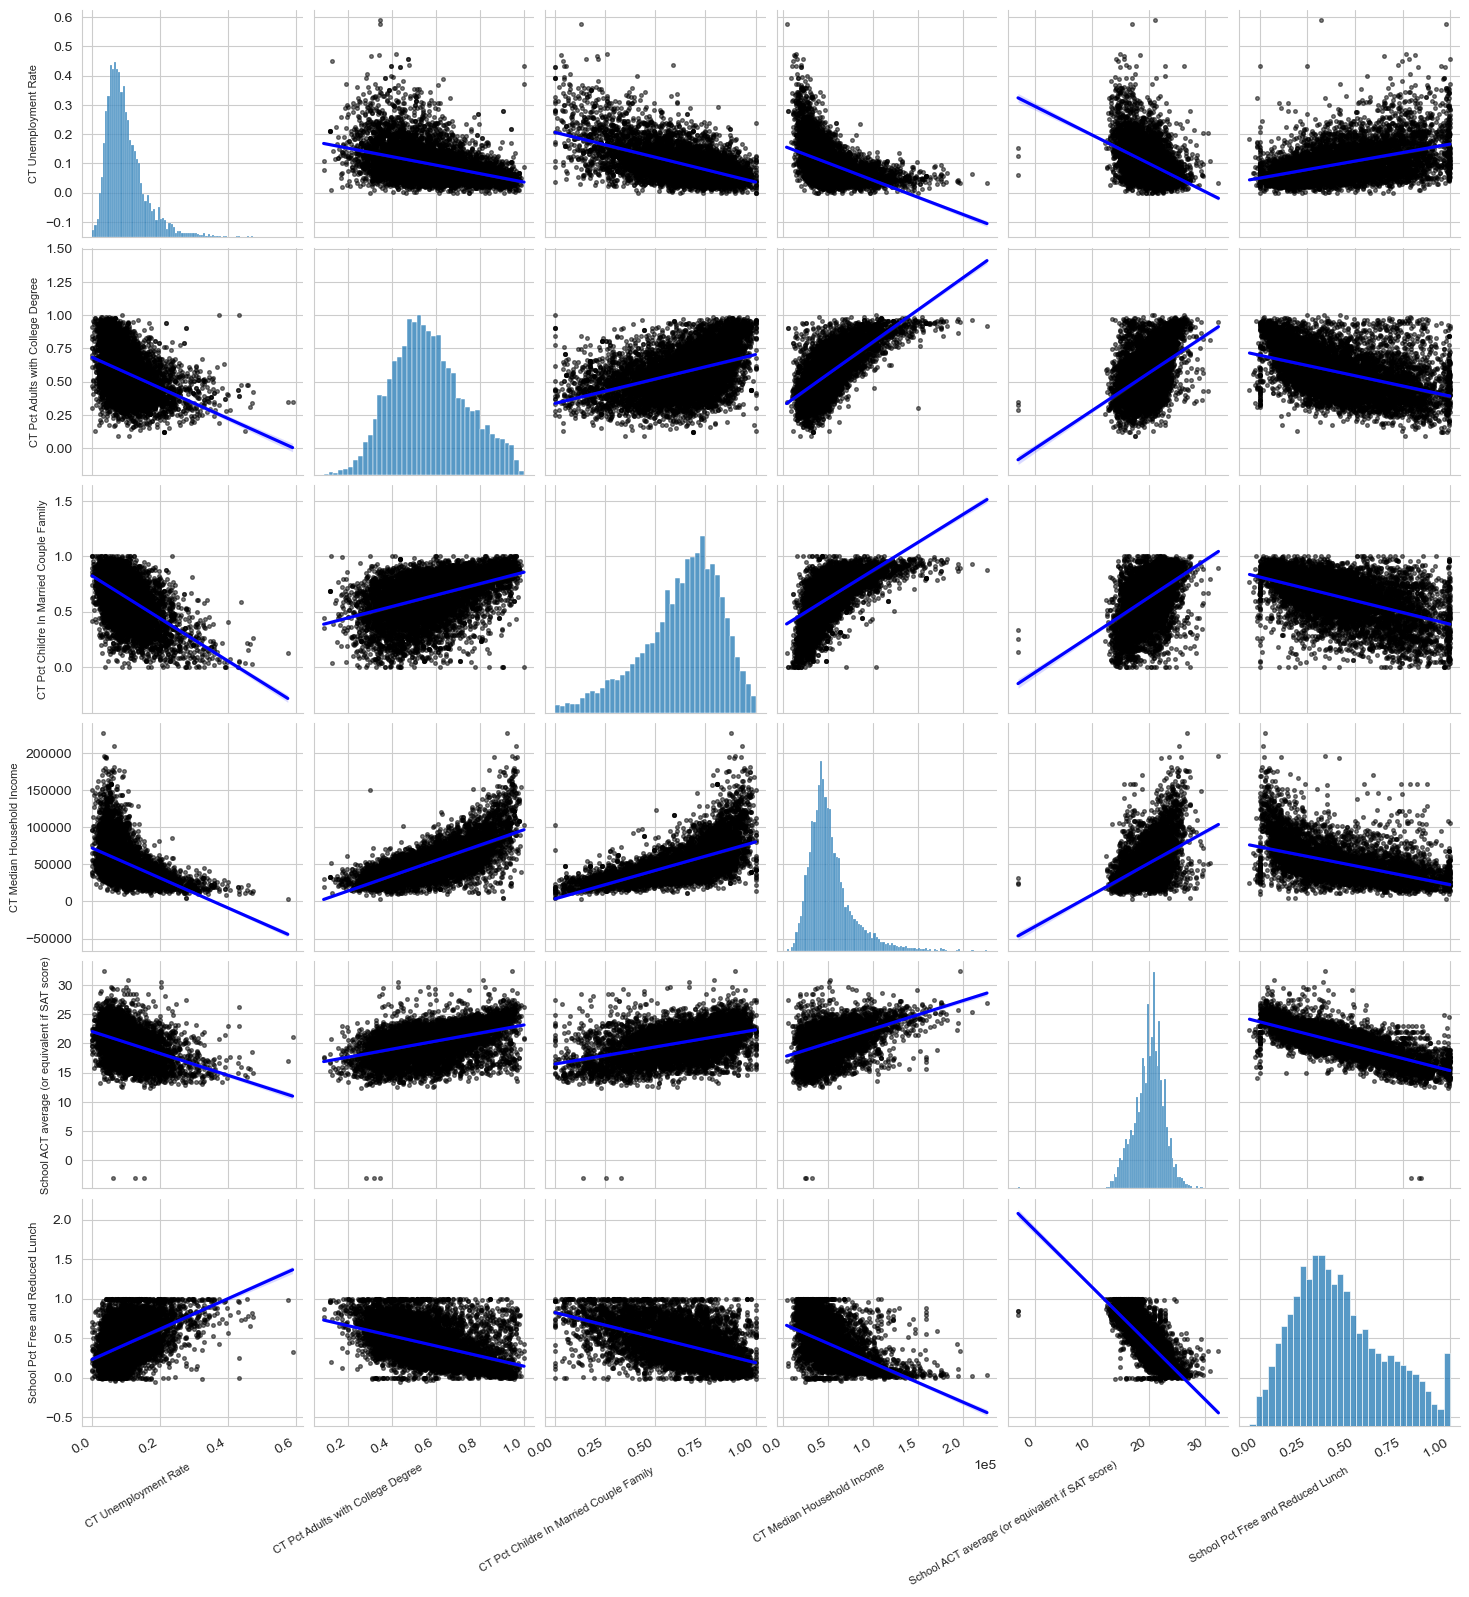

In [40]:
fig = sns.pairplot(
    edgap_info.drop(columns="NCESSCH School ID"),
    kind="reg", #regression
    plot_kws={
        "line_kws": {"color": "blue"},
        "scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':  # X-axis is Household Income
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')


plt.show()

^^ The above plots show us the same as the first, except now there is a regression line (in blue) that displays the trend of the data

#### Single Row Plotting

Plot a **SINGLE ROW** with **regression lines**:

Analyzing the relationship of `School ACT average` (exam scores) and all the other variables

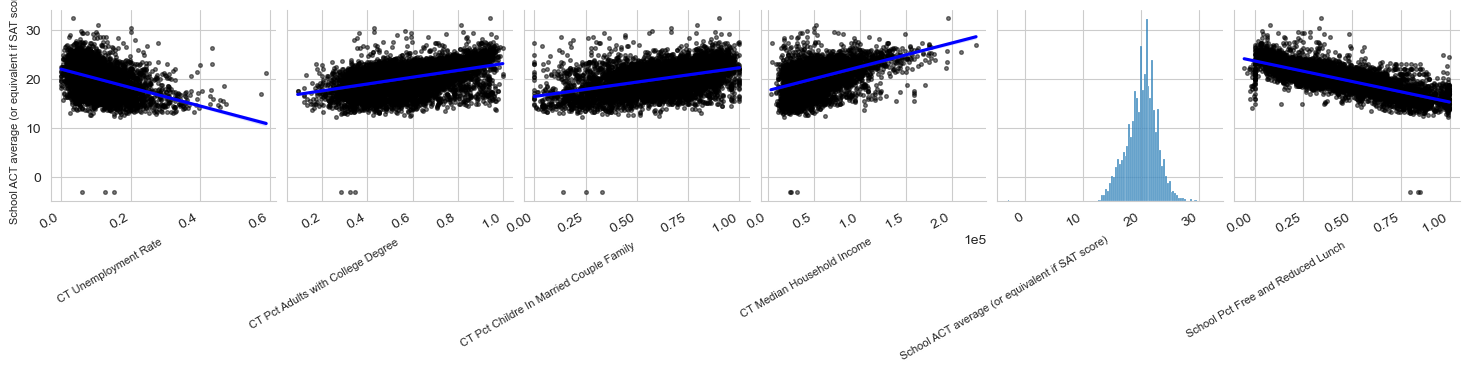

In [41]:
fig = sns.pairplot(
    edgap_info.drop(columns="NCESSCH School ID"),
    y_vars=['School ACT average (or equivalent if SAT score)'], # Y-axis is Exam Scores
    kind="reg", # Regression 
    plot_kws={
        "line_kws": {"color": "blue"},
        "scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

^^ The barplot above show us the relationship of `School ACT average` (exam scores) and all of the other variables, individually in their own plot display. This is easier to read becuase it allows us to focus on the relationships across the socioeconomic variables against 1 variable of interest.

#### Conclusion 

**Overall Conclusion of Initial Anlysis:** 
Based off of the regression line and plots above, we can see that there DOES appear to be a relationship between the original socioeconomic variables and average ACT/SAT exam score. There are some data values that are outliers from the main group, and these are values that we will have to take care of later on... but based off of the majority, I have confidence in the data we have at the moment to move forward with further analysis.


**Note:** We only performed an initial analysis on the **edgap_info** data set because this is where the data for the main socioeconomic variables and Average ACT/SAT exam scores are being stored. We can easily analyze the realtionships with this one data set, as the others are additional sources used to further analyze the relationships and paint a more precise picture to answer the original question.

## Data Prepping

### Renaming Columns

We will rename all of the columns for each of the data sets. This will help us better read the data and allow us to merge them on a single variable.

As expressed in the overall summary above, we want to join these data sets together... in order to do that, we want to make sure that all the naming conventions are the same and follow **best practices**.

This can be done **before OR after joining** the data set -- here we will do this before so that we can make the data easier to read earlier on.

#### EdGap data set

Columns right now

In [42]:
edgap_info.columns

Index(['NCESSCH School ID', 'CT Unemployment Rate',
       'CT Pct Adults with College Degree',
       'CT Pct Childre In Married Couple Family', 'CT Median Household Income',
       'School ACT average (or equivalent if SAT score)',
       'School Pct Free and Reduced Lunch'],
      dtype='object')

In [43]:
# Rename the columns in the edgap_info data set
edgap_info = edgap_info.rename(
    columns={
        "NCESSCH School ID": "id",
        "CT Pct Adults with College Degree": "percent_college",
        "CT Unemployment Rate": "rate_unemployment",
        "CT Pct Childre In Married Couple Family": "percent_married",
        "CT Median Household Income": "median_income",
        "School ACT average (or equivalent if SAT score)": "average_act",
        "School Pct Free and Reduced Lunch": "percent_lunch",
    }
)

Check to make sure it worked:

In [44]:
edgap_info.columns

Index(['id', 'rate_unemployment', 'percent_college', 'percent_married',
       'median_income', 'average_act', 'percent_lunch'],
      dtype='object')

#### School Info data set

Columns right now:

In [45]:
school_info.columns

Index(['SCHOOL_YEAR', 'FIPST', 'STATENAME', 'ST', 'SCH_NAME', 'LEA_NAME',
       'STATE_AGENCY_NO', 'UNION', 'ST_LEAID', 'LEAID', 'ST_SCHID', 'NCESSCH',
       'SCHID', 'MSTREET1', 'MSTREET2', 'MSTREET3', 'MCITY', 'MSTATE', 'MZIP',
       'MZIP4', 'LSTREET1', 'LSTREET2', 'LSTREET3', 'LCITY', 'LSTATE', 'LZIP',
       'LZIP4', 'PHONE', 'WEBSITE', 'SY_STATUS', 'SY_STATUS_TEXT',
       'UPDATED_STATUS', 'UPDATED_STATUS_TEXT', 'EFFECTIVE_DATE',
       'SCH_TYPE_TEXT', 'SCH_TYPE', 'RECON_STATUS', 'OUT_OF_STATE_FLAG',
       'CHARTER_TEXT', 'CHARTAUTH1', 'CHARTAUTHN1', 'CHARTAUTH2',
       'CHARTAUTHN2', 'NOGRADES', 'G_PK_OFFERED', 'G_KG_OFFERED',
       'G_1_OFFERED', 'G_2_OFFERED', 'G_3_OFFERED', 'G_4_OFFERED',
       'G_5_OFFERED', 'G_6_OFFERED', 'G_7_OFFERED', 'G_8_OFFERED',
       'G_9_OFFERED', 'G_10_OFFERED', 'G_11_OFFERED', 'G_12_OFFERED',
       'G_13_OFFERED', 'G_UG_OFFERED', 'G_AE_OFFERED', 'GSLO', 'GSHI', 'LEVEL',
       'IGOFFERED'],
      dtype='object')

In [46]:
# Rename the columns in the school_info data set
school_info = school_info.rename(
    columns={
        "SCHOOL_YEAR": "year",
        "SCH_NAME": "school_name",
        "NCESSCH": "id",
        "LCITY": "city",
        "LSTATE": "state",
        "LZIP": "zip_code",
        "SCH_TYPE_TEXT": "school_type",
        "LEVEL": "school_level",
        "CHARTER_TEXT": "charter"
    }
)

Check to make sure it worked:

In [47]:
school_info.columns

Index(['year', 'FIPST', 'STATENAME', 'ST', 'school_name', 'LEA_NAME',
       'STATE_AGENCY_NO', 'UNION', 'ST_LEAID', 'LEAID', 'ST_SCHID', 'id',
       'SCHID', 'MSTREET1', 'MSTREET2', 'MSTREET3', 'MCITY', 'MSTATE', 'MZIP',
       'MZIP4', 'LSTREET1', 'LSTREET2', 'LSTREET3', 'city', 'state',
       'zip_code', 'LZIP4', 'PHONE', 'WEBSITE', 'SY_STATUS', 'SY_STATUS_TEXT',
       'UPDATED_STATUS', 'UPDATED_STATUS_TEXT', 'EFFECTIVE_DATE',
       'school_type', 'SCH_TYPE', 'RECON_STATUS', 'OUT_OF_STATE_FLAG',
       'charter', 'CHARTAUTH1', 'CHARTAUTHN1', 'CHARTAUTH2', 'CHARTAUTHN2',
       'NOGRADES', 'G_PK_OFFERED', 'G_KG_OFFERED', 'G_1_OFFERED',
       'G_2_OFFERED', 'G_3_OFFERED', 'G_4_OFFERED', 'G_5_OFFERED',
       'G_6_OFFERED', 'G_7_OFFERED', 'G_8_OFFERED', 'G_9_OFFERED',
       'G_10_OFFERED', 'G_11_OFFERED', 'G_12_OFFERED', 'G_13_OFFERED',
       'G_UG_OFFERED', 'G_AE_OFFERED', 'GSLO', 'GSHI', 'school_level',
       'IGOFFERED'],
      dtype='object')

#### Geographical Info data set

Columns right now

In [48]:
geo_info.columns

Index(['NCESSCH', 'NAME', 'OPSTFIPS', 'STREET', 'CITY', 'STATE', 'ZIP',
       'STFIP', 'CNTY', 'NMCNTY', 'LOCALE', 'LAT', 'LON', 'CBSA', 'NMCBSA',
       'CBSATYPE', 'CSA', 'NMCSA', 'NECTA', 'NMNECTA', 'CD', 'SLDL', 'SLDU',
       'SURVYEAR'],
      dtype='object')

In [49]:
geo_info = geo_info.rename(
    columns={
        "NCESSCH": "id",
        "NAME": "school_name",
        "CITY": "city",
        "STATE": "state",
        "ZIP": "zip_code",
        "LOCALE": "locale_code",
        "SURVYEAR": "year"
    }
)

Make sure it worked

In [50]:
geo_info.columns

Index(['id', 'school_name', 'OPSTFIPS', 'STREET', 'city', 'state', 'zip_code',
       'STFIP', 'CNTY', 'NMCNTY', 'locale_code', 'LAT', 'LON', 'CBSA',
       'NMCBSA', 'CBSATYPE', 'CSA', 'NMCSA', 'NECTA', 'NMNECTA', 'CD', 'SLDL',
       'SLDU', 'year'],
      dtype='object')

#### Renamed Outputs

In [51]:
edgap_info.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641


In [52]:
school_info.head()

,year,FIPST,STATENAME,ST,school_name,LEA_NAME,STATE_AGENCY_NO,UNION,ST_LEAID,LEAID,...,G_10_OFFERED,G_11_OFFERED,G_12_OFFERED,G_13_OFFERED,G_UG_OFFERED,G_AE_OFFERED,GSLO,GSHI,school_level,IGOFFERED
0,2016-2017,1,ALABAMA,AL,Sequoyah Sch - Chalkville Campus,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
1,2016-2017,1,ALABAMA,AL,Camps,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
2,2016-2017,1,ALABAMA,AL,Det Ctr,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
3,2016-2017,1,ALABAMA,AL,Wallace Sch - Mt Meigs Campus,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
4,2016-2017,1,ALABAMA,AL,McNeel Sch - Vacca Campus,Alabama Youth Services,1,NaN,AL-210,100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported


In [53]:
school_info['id'].unique()

array([1.00002003e+10, 1.00002017e+10, 1.00002017e+10, ...,
       7.80003000e+11, 7.80003000e+11, 7.80003000e+11])

In [54]:
geo_info.head()

,id,school_name,OPSTFIPS,STREET,city,state,zip_code,STFIP,CNTY,NMCNTY,...,NMCBSA,CBSATYPE,CSA,NMCSA,NECTA,NMNECTA,CD,SLDL,SLDU,year
0,10000200277,Sequoyah Sch - Chalkville Campus,1,1000 Industrial School Road,Birmingham,AL,35220,01,01073,Jefferson County,...,"Birmingham-Hoover, AL",1,142,"Birmingham-Hoover-Talladega, AL",N,N,0106,01044,01020,2016
1,10000201667,Camps,1,1601 County Rd. 57,Prattville,AL,36067,01,01001,Autauga County,...,"Montgomery, AL",1,N,N,N,N,0102,01042,01030,2016
2,10000201670,Det Ctr,1,2109 Bashi Rd Bldg 509,Thomasville,AL,36784,01,01025,Clarke County,...,N,0,N,N,N,N,0107,01068,01024,2016
3,10000201705,Wallace Sch - Mt Meigs Campus,1,1000 Industrial School Road,Mount Meigs,AL,36057,01,01101,Montgomery County,...,"Montgomery, AL",1,N,N,N,N,0103,01075,01025,2016
4,10000201706,McNeel Sch - Vacca Campus,1,8950 Roebuck Blvd,Birmingham,AL,35206,01,01073,Jefferson County,...,"Birmingham-Hoover, AL",1,142,"Birmingham-Hoover-Talladega, AL",N,N,0107,01058,01020,2016


Using the `.head()` attribute, we can see the first 5 rows of each data set organized with the re-named variables.

### CREATING NEW VARIABLES + Summary Statistics
`geoassignment`, `percent_city`,... ,`percent_rural`

We want to create few additonal columns in our data that will help us better analyze the relationship between ACT/SAT exam scores and geoassignment. 

These new columns will be added to the **Geo_Info** dataset:

- `geoassignment`, which will represent the labels - City, Subarb, Town, or Rural - based off of the locale code, for each school.
  
- 4 Summary Statistics:
    - `st_percent_city`, which will represent the states % of city schools (locale 11, 12, 13)
    - `st_percent_subarb`, which will represent the states % of suburban schools (locale 21, 22, 23)
    - `st_percent_town`, which will represent the states % of town schools  (locale 31, 32, 33)
    - `st_percent_rural`, which will represent the states % of rural schools (locale 41, 42, 43)


**Note:** These follow the assignment rules in the **EDGE Geocode Tech Doc** here: https://nces.ed.gov/programs/edge/docs/EDGE_GEOCODE_PUBLIC_TECHDOC.pdf

#### Creating `geoassinment` variable

In [55]:
geo_info['locale_code'] = pd.to_numeric(geo_info['locale_code'], errors='coerce')

# Create a function to map codes to categories
def map_geoassignment(code):
    if pd.isna(code):
        return None
    elif code in [11, 12, 13]:
        return 'City'
    elif code in [21, 22, 23]:
        return 'Suburban'
    elif code in [31, 32, 33]:
        return 'Town'
    elif code in [41, 42, 43]:
        return 'Rural'
    else:
        return 'Unknown'

# Apply the mapping
geo_info['geoassignment'] = geo_info['locale_code'].apply(map_geoassignment)

In [56]:
# See if it worked
geo_info.head()

,id,school_name,OPSTFIPS,STREET,city,state,zip_code,STFIP,CNTY,NMCNTY,...,CBSATYPE,CSA,NMCSA,NECTA,NMNECTA,CD,SLDL,SLDU,year,geoassignment
0,10000200277,Sequoyah Sch - Chalkville Campus,1,1000 Industrial School Road,Birmingham,AL,35220,01,01073,Jefferson County,...,1,142,"Birmingham-Hoover-Talladega, AL",N,N,0106,01044,01020,2016,Suburban
1,10000201667,Camps,1,1601 County Rd. 57,Prattville,AL,36067,01,01001,Autauga County,...,1,N,N,N,N,0102,01042,01030,2016,Rural
2,10000201670,Det Ctr,1,2109 Bashi Rd Bldg 509,Thomasville,AL,36784,01,01025,Clarke County,...,0,N,N,N,N,0107,01068,01024,2016,Rural
3,10000201705,Wallace Sch - Mt Meigs Campus,1,1000 Industrial School Road,Mount Meigs,AL,36057,01,01101,Montgomery County,...,1,N,N,N,N,0103,01075,01025,2016,Rural
4,10000201706,McNeel Sch - Vacca Campus,1,8950 Roebuck Blvd,Birmingham,AL,35206,01,01073,Jefferson County,...,1,142,"Birmingham-Hoover-Talladega, AL",N,N,0107,01058,01020,2016,City


#### Creatin `percent_ABC` SUMMARY STATISTIC

In [57]:
geo_info.columns

Index(['id', 'school_name', 'OPSTFIPS', 'STREET', 'city', 'state', 'zip_code',
       'STFIP', 'CNTY', 'NMCNTY', 'locale_code', 'LAT', 'LON', 'CBSA',
       'NMCBSA', 'CBSATYPE', 'CSA', 'NMCSA', 'NECTA', 'NMNECTA', 'CD', 'SLDL',
       'SLDU', 'year', 'geoassignment'],
      dtype='object')

In [58]:
# Group by state and geoassignment to count schools
state_locale = (
    geo_info.groupby(['state', 'geoassignment'])
    .size()
    .reset_index(name='school_count')
)

# Compute total schools per state
state_totals = (
    geo_info.groupby('state')
    .size()
    .reset_index(name='total_schools')
)

# Merge totals 
state_locale = state_locale.merge(state_totals, on='state')

# Compute percentage of each locale type per state
state_locale['percentage'] = (state_locale['school_count'] / state_locale['total_schools']) * 100

# Pivot wider to get one row per state with 4 columns of percentages
state_percentages = (
    state_locale.pivot(index='state', columns='geoassignment', values='percentage')
    .fillna(0)
    .reset_index()
)

# Rename columns to match NCES style
state_percentages.columns.name = None
state_percentages = state_percentages.rename(columns={
    'City': 'st_percent_city',
    'Suburban': 'st_percent_suburb',
    'Town': 'st_percent_town',
    'Rural': 'st_percent_rural'
})

# See if it worked
print(state_percentages.head())


  state  st_percent_city  st_percent_rural  st_percent_suburb  st_percent_town
0    AK        18.809981         60.460653           2.879079        17.850288
1    AL        23.404255         44.487427          17.085751        15.022566
2    AP         0.000000          6.122449           0.000000         2.040816
3    AR        22.563177         44.494585          11.101083        21.841155
4    AS         0.000000         32.142857           0.000000        67.857143


<br>

**Save this new data to additional file in case we need it later:**

In [59]:
state_percentages.to_csv(
    '/Users/alyssa.zukas/data5100/education/data/state_locale_percentages.csv',
    index=False
)

<br>

**Merge this into the `geo_info` dataset to be represented**

In [60]:
# Make the geo_info dataset show these summary statistics
geo_info = geo_info.merge(
    state_percentages,
    on='state',
    how='left'
)

In [61]:
geo_info.head()

,id,school_name,OPSTFIPS,STREET,city,state,zip_code,STFIP,CNTY,NMCNTY,...,NMNECTA,CD,SLDL,SLDU,year,geoassignment,st_percent_city,st_percent_rural,st_percent_suburb,st_percent_town
0,10000200277,Sequoyah Sch - Chalkville Campus,1,1000 Industrial School Road,Birmingham,AL,35220,01,01073,Jefferson County,...,N,0106,01044,01020,2016,Suburban,23.404255,44.487427,17.085751,15.022566
1,10000201667,Camps,1,1601 County Rd. 57,Prattville,AL,36067,01,01001,Autauga County,...,N,0102,01042,01030,2016,Rural,23.404255,44.487427,17.085751,15.022566
2,10000201670,Det Ctr,1,2109 Bashi Rd Bldg 509,Thomasville,AL,36784,01,01025,Clarke County,...,N,0107,01068,01024,2016,Rural,23.404255,44.487427,17.085751,15.022566
3,10000201705,Wallace Sch - Mt Meigs Campus,1,1000 Industrial School Road,Mount Meigs,AL,36057,01,01101,Montgomery County,...,N,0103,01075,01025,2016,Rural,23.404255,44.487427,17.085751,15.022566
4,10000201706,McNeel Sch - Vacca Campus,1,8950 Roebuck Blvd,Birmingham,AL,35206,01,01073,Jefferson County,...,N,0107,01058,01020,2016,City,23.404255,44.487427,17.085751,15.022566


<br>

**Explanation:** What we did above allows us to better analyze the relationship between school performance and geoassignment. 

Based off of the state that the school is in - we can also see the percentage of schools for each state's geoassignment.

Now we can use this data to analyze each states geoassignment demographic and average ACT/SAT exam scores. For example, we may find that states with more rural schools tend to have lower ACT/SAT exam scores.

### Converting Data Types

We want to join the dataframes using the **School ID** as the key indicator, noted as `id` in all the data frames thanks to us renaming this variable early on. 

In order to do this, we need to make sure the data types of this key variable is the same in each of the data frames.  

Right now these data types are NOT the same... we know that the datatype of school ID is an `object` in the **EdGap** data, a `float64` is the **School Information** data, and an `int64` in the **Geographical Information** data.

#### EdGap Info

In [62]:
edgap_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7986 non-null   object 
 1   rate_unemployment  7972 non-null   float64
 2   percent_college    7973 non-null   float64
 3   percent_married    7961 non-null   float64
 4   median_income      7966 non-null   float64
 5   average_act        7986 non-null   float64
 6   percent_lunch      7986 non-null   float64
dtypes: float64(6), object(1)
memory usage: 436.9+ KB


We will not be converting any data types for the EdGap data frame. The key variable we aim to merge on here, `id`, is already an `object`, so we aim to change the data types in the other data frames to match this.

#### School Info 

For this dataframe... we will change the school ID variable data type from `float64` to an `object`.

In [63]:
school_info['id'] = school_info['id'].astype('object')

In [64]:
# Check to make sure it worked
school_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 65 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 102183 non-null  object 
 1   FIPST                102183 non-null  int64  
 2   STATENAME            102183 non-null  object 
 3   ST                   102183 non-null  object 
 4   school_name          102183 non-null  object 
 5   LEA_NAME             102183 non-null  object 
 6   STATE_AGENCY_NO      102183 non-null  object 
 7   UNION                2533 non-null    float64
 8   ST_LEAID             102183 non-null  object 
 9   LEAID                102183 non-null  object 
 10  ST_SCHID             102183 non-null  object 
 11  id                   102181 non-null  object 
 12  SCHID                102181 non-null  float64
 13  MSTREET1             102181 non-null  object 
 14  MSTREET2             1825 non-null    object 
 15  MSTREET3         

In the above code we used the `.astype()` attribute to change the datatype of the School ID. <br>
You can see above in line #8 that the **Dtype** (data type) for the key indicator, `id`, is now an `object`.

#### Geographical Info

For this dataframe we will change the school ID variable data type from an `int64` to an `object`.

In [65]:
geo_info['id'] = geo_info['id'].astype('object')

In [66]:
# Check to see if it worked
geo_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102173 entries, 0 to 102172
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 102173 non-null  object 
 1   school_name        102173 non-null  object 
 2   OPSTFIPS           102173 non-null  int64  
 3   STREET             102173 non-null  object 
 4   city               102173 non-null  object 
 5   state              102173 non-null  object 
 6   zip_code           102173 non-null  int64  
 7   STFIP              102173 non-null  object 
 8   CNTY               102173 non-null  object 
 9   NMCNTY             102173 non-null  object 
 10  locale_code        102053 non-null  float64
 11  LAT                102173 non-null  float64
 12  LON                102173 non-null  float64
 13  CBSA               102173 non-null  object 
 14  NMCBSA             102173 non-null  object 
 15  CBSATYPE           102173 non-null  int64  
 16  CS

You can see above in line #0 that the **Dtype** (data type) for the key indicator, `id`,  is now an `object`.

### Converting Data Formatting

In order to move onto out exploratory data analysis stage, we need one clean file that contains of the data we want from all three dataframes -- EdGap, School Information, and Geographical Information. 

We went ahead and changed all of the data types, now we want to also make sure the formatting matches across all the School IDs.

**Verify the data types are the same**

In [67]:
# Verify the data types
print("edgap_info ID Data Type:")
print(edgap_info['id'].dtype)

print("\nschool_info ID Data Type:")
print(school_info['id'].dtype)

print("\ngeo_info ID Data Type:")
print(geo_info['id'].dtype)

edgap_info ID Data Type:
object

school_info ID Data Type:
object

geo_info ID Data Type:
object


**Check the formatting**

In [68]:
# Compare the formatting
print("edgap_info IDs:")
print(edgap_info['id'].head().tolist())

print("\nschool_info IDs:")
print(school_info['id'].head().tolist())

print("\ngeo_info IDs:")
print(geo_info['id'].head().tolist())

edgap_info IDs:
[100001600143, 100008000024, 100008000225, 100017000029, 100018000040]

school_info IDs:
[10000200277.0, 10000201667.0, 10000201670.0, 10000201705.0, 10000201706.0]

geo_info IDs:
[10000200277, 10000201667, 10000201670, 10000201705, 10000201706]


**Change the formattting**

In [69]:
# Convert IDs to 12-character zero-padded strings
school_info['id'] = school_info['id'].astype(str).str.split('.').str[0].str.zfill(12)
edgap_info['id'] = edgap_info['id'].astype(str).str.split('.').str[0].str.zfill(12)
geo_info['id'] = geo_info['id'].astype(str).str.split('.').str[0].str.zfill(12)

print("edgap_info IDs:")
print(edgap_info['id'].head(15).tolist())

print("\nschool_info IDs:")
print(school_info['id'].head(15).tolist())

print("\ngeo_info IDs:")
print(geo_info['id'].head(15).tolist())

edgap_info IDs:
['100001600143', '100008000024', '100008000225', '100017000029', '100018000040', '100019000050', '100020000238', '100020000239', '100020000240', '100023000209', '100027000080', '100068000085', '100068000090', '100079000095', '100081000100']

school_info IDs:
['010000200277', '010000201667', '010000201670', '010000201705', '010000201706', '010000201876', '010000500870', '010000500871', '010000500879', '010000500889', '010000501616', '010000502150', '010000600193', '010000600872', '010000600876']

geo_info IDs:
['010000200277', '010000201667', '010000201670', '010000201705', '010000201706', '010000201876', '010000500870', '010000500871', '010000500879', '010000500889', '010000501616', '010000502150', '010000600193', '010000600872', '010000600876']


<br>

**Explanation:** The point of checking the data type is to vertify that our previous change is still accurate - When we changed the data type of the School Information ID from a `float` to an `object`. We can see from the output above that data type for the School ID in all three dataframes are `objects`. We are good to go on the data type!


We also checked the formatting of the school IDs in each of the data sets... as we can see above, they clearly are not the same. `10000200277.0` will not read the same as `10000200277`. 
My first initial thought was to remove the `.0` at the end, but we can count that they're are 12-digits in EdGap IDs and only 11-digits in School Inforation IDs.


In the last segment of code, we converted the ID in both datasets to 12-character strings. Although the EdGap IDs were already in this format, we went ahead and applied this change to all of them. Now you can see that each of the IDs have 12-digits in them. 

After these two changes, we should be ready to merge the datasets together!!

### Joining the Data Frames

#### Choosing how to merge 

The way in which we merge the datasets with determine what values in the data are kept for exploratory analysis. The way tell pandas how to do this comes from what type of merge tell it to do.

**Inner Join** <br>
An inner join - denoted as `inner` - only keeps rows that exist in both data frames... meaning that this is good for overlapping data because it only keeps what **matches**.

**Left Join** <br>
A left join - denoted as `left` - keeps all of the rows from the **left** dataframe + what matches from the right... this means that mising matches on the right become NaN. This is good for when we want to merge an additional dataset while keeping the main dataset intact.

**Right Join** <br>
A right join - denoted as `right` - keeps all of the rows from the **right** dataframe + matches in the left... this means that missing matches on left become NaN. This is rare to use, as we might as well use the left-join in this case, but it is good is we want to filter the original dataset to match an additional/new one.

**Outer Join** <br>
An outter join - denoted as `outer` - keeps all of the rows from **both** data frames ... meaning that this is good when we want a union of **ALL the records** combined, because it merges literally everything in each data set and fills the missing values as NaN. 

<br>

#### Merge 1: School Info + Geogarphical Info

As mentioned prior, we need one clean file that contains the data we want from all three dataframes -- EdGap, School Information, and Geographical Information. 

We will first start off by merging the **School Information** and **Geographical Information** dataframes together!
If done correctly this create a newly combined dataframe, which we will call `school_master`, that displays all of the values for the specific columns of our choosing from BOTH dataframes. We want to do this first because they both contain data that describes key information for each school, thus giving a sort of **master data set** of school information.

**Note:** Since these are both data sets containing data from the NCES, the merge will be clean and lossless even if we did not rename the columns by now.

<br>

Look at what columns we will be working with

In [70]:
school_info.columns

Index(['year', 'FIPST', 'STATENAME', 'ST', 'school_name', 'LEA_NAME',
       'STATE_AGENCY_NO', 'UNION', 'ST_LEAID', 'LEAID', 'ST_SCHID', 'id',
       'SCHID', 'MSTREET1', 'MSTREET2', 'MSTREET3', 'MCITY', 'MSTATE', 'MZIP',
       'MZIP4', 'LSTREET1', 'LSTREET2', 'LSTREET3', 'city', 'state',
       'zip_code', 'LZIP4', 'PHONE', 'WEBSITE', 'SY_STATUS', 'SY_STATUS_TEXT',
       'UPDATED_STATUS', 'UPDATED_STATUS_TEXT', 'EFFECTIVE_DATE',
       'school_type', 'SCH_TYPE', 'RECON_STATUS', 'OUT_OF_STATE_FLAG',
       'charter', 'CHARTAUTH1', 'CHARTAUTHN1', 'CHARTAUTH2', 'CHARTAUTHN2',
       'NOGRADES', 'G_PK_OFFERED', 'G_KG_OFFERED', 'G_1_OFFERED',
       'G_2_OFFERED', 'G_3_OFFERED', 'G_4_OFFERED', 'G_5_OFFERED',
       'G_6_OFFERED', 'G_7_OFFERED', 'G_8_OFFERED', 'G_9_OFFERED',
       'G_10_OFFERED', 'G_11_OFFERED', 'G_12_OFFERED', 'G_13_OFFERED',
       'G_UG_OFFERED', 'G_AE_OFFERED', 'GSLO', 'GSHI', 'school_level',
       'IGOFFERED'],
      dtype='object')

In [71]:
geo_info.columns

Index(['id', 'school_name', 'OPSTFIPS', 'STREET', 'city', 'state', 'zip_code',
       'STFIP', 'CNTY', 'NMCNTY', 'locale_code', 'LAT', 'LON', 'CBSA',
       'NMCBSA', 'CBSATYPE', 'CSA', 'NMCSA', 'NECTA', 'NMNECTA', 'CD', 'SLDL',
       'SLDU', 'year', 'geoassignment', 'st_percent_city', 'st_percent_rural',
       'st_percent_suburb', 'st_percent_town'],
      dtype='object')

<br>

**Merge them together on our selected columns**

In [72]:
# LEFT Join with specific columns
school_master = school_info[['year','school_name', 'id', 'city', 'state', 'zip_code', 'school_type', 'school_level', 'charter']
].merge(
    geo_info[['id', 'locale_code', 'geoassignment', 'st_percent_city', 'st_percent_town', 'st_percent_rural', 'st_percent_suburb']], 
    on='id', 
    how='left'
)

# Check to make sure it worked
school_master

,year,school_name,id,city,state,zip_code,school_type,school_level,charter,locale_code,geoassignment,st_percent_city,st_percent_town,st_percent_rural,st_percent_suburb
0,2016-2017,Sequoyah Sch - Chalkville Campus,010000200277,Birmingham,AL,35220,Alternative School,High,No,21.0,Suburban,23.404255,15.022566,44.487427,17.085751
1,2016-2017,Camps,010000201667,Prattville,AL,36067,Alternative School,High,No,41.0,Rural,23.404255,15.022566,44.487427,17.085751
2,2016-2017,Det Ctr,010000201670,Thomasville,AL,36784,Alternative School,High,No,41.0,Rural,23.404255,15.022566,44.487427,17.085751
3,2016-2017,Wallace Sch - Mt Meigs Campus,010000201705,Mount Meigs,AL,36057,Alternative School,High,No,41.0,Rural,23.404255,15.022566,44.487427,17.085751
4,2016-2017,McNeel Sch - Vacca Campus,010000201706,Birmingham,AL,35206,Alternative School,High,No,12.0,City,23.404255,15.022566,44.487427,17.085751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102178,2016-2017,GLADYS A. ABRAHAM ELEMENTARY SCHOOL,780003000025,Saint Thomas,VI,802,Regular School,Elementary,Not applicable,33.0,Town,0.000000,100.000000,0.000000,0.000000
102179,2016-2017,ULLA F MULLER ELEMENTARY SCHOOL,780003000026,Saint Thomas,VI,802,Regular School,Elementary,Not applicable,33.0,Town,0.000000,100.000000,0.000000,0.000000
102180,2016-2017,YVONNE BOWSKY ELEMENTARY SCHOOL,780003000027,Saint Thomas,VI,802,Regular School,Elementary,Not applicable,33.0,Town,0.000000,100.000000,0.000000,0.000000
102181,2016-2017,CANCRYN JUNIOR HIGH SCHOOL,780003000033,Saint Thomas,VI,804,Regular School,Middle,Not applicable,33.0,Town,0.000000,100.000000,0.000000,0.000000


**Explanation:** In the above code, we are choosing to merge the two data frames together, while also avoiding duplicates in columns -- which, for example, would output something like `year_x` and `year_y` if we selected `year` from both the data frames in the merge -- Since we already know that the data from both these datasets are coming from the same year, we really only need one column to display the year for each row. <br>
This is the same concept for the school name, city, state, zipcode, school type, and a school level... These values don't change across the dataframes. 

And since we are using the School Information dataset as our main dataframe, we will add in these columns from this dataset while only using the Geographical Information dataframe to get the `local_code` and `geoassignment`... Plus the summary statistics we calculated earlier.

This also explains why we chose to do a **left join**... Because we want to use the School Information data frame as the main set of data, while adding in additional data from the Geographical data.

This means that we are keeping all schools from the **school_info** dataset.
So any **school IDs** that didn’t have a matching entry in **geo_info** will show `NaN`. This will not affect the data but may affect how we interpret, analyze, and model the data later on... Whether we choose to **drop or impute** these missing values later on will depend on how many missing values there are. 

<br>

**Check how many entries we have now**

In [73]:
print(school_master.shape)

(102183, 15)


In [74]:
print(school_info.shape)

(102183, 65)


In [75]:
print(geo_info.shape)

(102173, 29)


In the above outputs, we checked the `shape` of our newly merged data set against the two original. <br>
We can see that we have we same amount of entries as **school_info**, which was the goal.

#### Check how many schools did not have a `local_code`

We want to check how many schools in the School Information dataframe did not get assigned a locale code from the Geographical Information dataframe on the merge.

In [76]:
geo_info['locale_code'].nunique()

12

In [77]:
school_master['locale_code'].nunique()

12

In [78]:
# Count the NaN values
missing_count = school_master['locale_code'].isna().sum()
total = len(school_master)
print(f"Missing locale_code for {missing_count} out of {total} schools ({missing_count/total:.2%})")

Missing locale_code for 131 out of 102183 schools (0.13%)


**Observation:** In the above outputs we can see that there are **12** locale codes represented in the original Geographical Information  data set, and in our newly merged dataframe - `school_master`- **all 12** of those locale codes had matching IDs with schools in the School Information data set. <br>
This tells me that there is not an issue with coverage in the `locale_code` assignments for the schools in our data sets. 

Just out of curiousity, we also went further and decided to count how many of these school IDs did not match - thus did not get assigned a locale code. We can see above that there are only **131 schools out of the total 102183 school** that did not have an `id` that matched a school with a locale code assignment. This is less than 1% of the data... so it is safe to assume that we can move forward in the analysis without worrying about missing values altering our findings.

#### Merge 2: EdGap Info + School Master

Now that we have a dataframe that represents all of the school information we need - `school_master` - we want to merge this together with the EdGap data - `edgap_info` - to get all of the data in one frame. 

**Note:** In a real world scenerio we would just jump stright to merging the Geographical Information dataset - `geo_info` - with the EdGap dataset, since this would cover all of the variables we need. But in an effort to follow along with class modules and gain extra practice, we will be merging all 3. 

**Merge the dataframes together**

In [114]:
school_master.columns

Index(['year', 'school_name', 'id', 'city', 'state', 'zip_code', 'school_type',
       'school_level', 'charter', 'locale_code', 'geoassignment',
       'st_percent_city', 'st_percent_town', 'st_percent_rural',
       'st_percent_suburb'],
      dtype='object')

In [80]:
# Merge the EdGap and school_master dataframes on a left-join
df = edgap_info.merge(
    school_master,
    on='id',
    how='left'
)

# Check to make sure it worked
df

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,school_name,city,...,zip_code,school_type,school_level,charter,locale_code,geoassignment,st_percent_city,st_percent_town,st_percent_rural,st_percent_suburb
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,Delaware Military Academy,Wilmington,...,19804,Regular School,High,Yes,21.0,Suburban,17.521368,16.239316,15.811966,50.427350
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,Middletown High School,Middletown,...,19709,Regular School,High,No,31.0,Town,17.521368,16.239316,15.811966,50.427350
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,Appoquinimink High School,Middletown,...,19709,Regular School,High,No,41.0,Rural,17.521368,16.239316,15.811966,50.427350
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,Cape Henlopen High School,Lewes,...,19958,Regular School,High,No,32.0,Town,17.521368,16.239316,15.811966,50.427350
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,Caesar Rodney High School,Camden,...,19934,Regular School,High,No,22.0,Suburban,17.521368,16.239316,15.811966,50.427350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7981,560530200294,0.034549,0.590780,0.720077,64891.0,18.500000,0.232156,2016-2017,Rock Springs High School,Rock Springs,...,82901,Regular School,High,No,33.0,Town,14.516129,32.258065,51.612903,1.612903
7982,560569000311,0.069538,0.633860,0.808841,44603.0,22.300000,0.083871,2016-2017,Big Horn High School,Big Horn,...,82833,Regular School,High,No,42.0,Rural,14.516129,32.258065,51.612903,1.612903
7983,560569500360,0.035159,0.764566,0.776570,44896.0,21.500000,0.184829,2016-2017,Sheridan High School,Sheridan,...,82801,Regular School,High,No,33.0,Town,14.516129,32.258065,51.612903,1.612903
7984,560576200324,0.063877,0.670532,0.879324,92134.0,19.700000,0.112583,2016-2017,Green River High School,Green River,...,82935,Regular School,High,No,33.0,Town,14.516129,32.258065,51.612903,1.612903


**Explanation:** In the above code we chose to do a **left join** with the EdGap data and the `school_master` dataframe together on the key indicator, `id`. We chose **EdGap** data as the main/left frame. 

This is to focus on the main variables that we will be analyzing - which are variables in the EdGap dataframe. This reduces the amount of missing values we have to deal with, since we are now only working with the **subset of EdGap schools**.

At the end of the merge, we get our **final data frame** - named `df` - that contains all the variables that we need to further analyze the relationship between ACT/SAT Exam scores and the 6 Socioeconomic Variables selected.

<br>

### Quality Control

There are natural bounds for the numerical variables in our final data set.

We want to check the minimum and maximum values in each column, so we can analyze where we may want to eliminate values that can be considered out of range. 

This will help us reduce the amout of outliers represented in our visuals later on, thus painting a more clear picture of the relationships we aim to analyze.

#### Out-of-range values

In [81]:
df.describe()

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,locale_code,st_percent_city,st_percent_town,st_percent_rural,st_percent_suburb
count,7972.000000,7973.000000,7961.000000,7966.000000,7986.000000,7986.000000,7898.000000,7898.000000,7898.000000,7898.000000,7898.000000
mean,0.098730,0.568930,0.633440,52026.905222,20.181532,0.420651,26.985313,25.902466,12.762533,26.449866,34.885135
std,0.058959,0.165704,0.196764,24228.057079,2.595201,0.239754,11.803863,8.065985,4.946957,9.078810,15.558099
min,0.000000,0.091493,0.000000,3589.000000,-3.070818,-0.054545,11.000000,9.973149,2.133333,9.090909,1.612903
25%,0.058655,0.450828,0.523810,36597.250000,18.600000,0.238501,21.000000,19.745431,9.856397,20.445920,22.622951
50%,0.085649,0.554979,0.667594,46833.500000,20.400000,0.381570,22.000000,23.932638,13.301054,27.105624,36.456850
75%,0.123376,0.676571,0.777135,61369.250000,21.910867,0.575447,41.000000,28.422720,14.077670,34.477034,42.125237
max,0.590278,1.000000,1.000000,226181.000000,32.362637,0.998729,43.000000,44.629287,32.258065,51.612903,78.365938


In [82]:
df.loc[df['percent_lunch'] < 0, 'percent_lunch'] = np.nan

In [83]:
df.loc[df['average_act'] < 1, 'average_act'] = np.nan

In the above code, we used the `describe()` method to compute descriptive statistics of each variable. <br>
We then set out-of-range values to NaN using `np.nan` for the `percent_lunch` and `average_act` columns. 

#### Filtering the Data

Now we want to check the types, levels and charter status of all the schools, and count how many there are for each school in our dataset.

In [84]:
# See all the 'types' of schools in our dataset
# Count how many there are for each
df['school_type'].value_counts()

school_type
Regular School                 7885
Alternative School               10
Special Education School          2
Career and Technical School       1
Name: count, dtype: int64

In [85]:
# See all the school 'levels' in our dataset
# Count how many there are for each
df['school_level'].value_counts()

school_level
High            7230
Other            631
Not reported      35
Elementary         2
Name: count, dtype: int64

In [86]:
# See all the school 'charters' in our dataset
# Count how many there are for each
df['charter'].value_counts()

charter
No                7329
Yes                352
Not applicable     217
Name: count, dtype: int64

<br>

**Explanation** In the above chunks of code we outputted the types, levels, and charter status of each scchool in our dataset. We did this so that we can decide how we want to further filter the data for our analysis. 

The key points we took from the outputs are that there is **7885** regular schools, **7230** high schools, and majority are **not charter shcools**.

<br>

**Keep only High Schools**

In [87]:
df = df.loc[df['school_level'] == 'High']

# Check to see if it worked
df['school_level'].unique()

array(['High'], dtype=object)

**Keep only public/regular schools**

In [88]:
df = df.loc[df['school_type'] == 'Regular School']

# Check to see if it worked
df['school_type'].unique()

array(['Regular School'], dtype=object)

**Keep only Non-Charter schols**

In [89]:
df = df.loc[df['charter'] == 'No']

# Check to see if it worked
df['charter'].unique()

array(['No'], dtype=object)

**Explanation:** In order to draw conclusions from out future visualizations, we want to focus on a subset of the schools in the dataset. We saw prior that the data consists on majroity public, non-charter, highscools. 

So in the above three sections of code, we filtered the dataset to only contain these subset of schools. 

#### Handling Duplicates

Check for duplicates

In [90]:
df.duplicated().sum()

np.int64(0)

**Explanation:** In order to properly analyze the data we want to make sure there are not any unnecessary repetitions in the values being represented. Based off of our above output, it does not appear that there are any duplicates in this dataset. Although it ispossible that there are incorrectly recorded values in the dataset, we will not be worrying about that here.

#### Identifying Missing Values

Before building visualizations or beginnging out final analysis, we need to make sure the relationships we are seeing are as accurate as possible. 

Identify any missing values in the dataframe will help us see if there is a coverage gap in any of the variables we are analyzing, and will also help us determine if we want to drop or impute these values later.

In [91]:
# Count missing values for each variable
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,12
percent_college,11
percent_married,19
median_income,15
average_act,3
percent_lunch,19
year,0
school_name,0
city,0


In [92]:
# Show percetage of missing values
percent_missing = df.isna().mean().round(4) * 100
percent_missing.to_frame(name='Percent Missing Values')

,Percent Missing Values
id,0.00
rate_unemployment,0.18
percent_college,0.16
percent_married,0.28
median_income,0.22
average_act,0.04
percent_lunch,0.28
year,0.00
school_name,0.00
city,0.00


**Explanation:** In the above code we asked pandas to count how many missing values there are in each column of our data. We can see in the output that there are **more than 10 missing values** for the columns: unemployment rate (`rate_unemployment`), percent of those that are college educated (`percent_college`), percent of married-couple families (`percent_married`), median income (`median_income`), and percent of students that qualify for school lunch programs (`percent_lunch`).

We also went further to display how much of the values in each variable are missing in terms of percentage. The key points here that draw my attention are that **nearly 30%** of values for `percent_lunch` and `percent_married` contain missing values.

#### Dropping Missing Values

**Remove schools where there are no ACT/SAT scores**

In [93]:
df = df.dropna(subset=['average_act'])

# Check to make sure it worked
df['average_act'].isna().sum()

np.int64(0)

**Explanation:** Since we saw prior that there are only **3 missing values** for the ACT/SAT exam scores, and choosing to imoute these values with average scores would be conflicting to the data, we are choosing to drop the schools that are missing these values so they do not cause any confusion when analyzing our data further. 

Now just because we are applying this method to the missing exam scores does **not** mean that this is a good method to apply for the other missing values in other variables. <br>
If we drop rows that have `NaN` for any socioeconomic variables, then we will negatively affect our analysis using the variables where data was present. 

So, we will not drop the rows in these other socioeconomic variables that are missing values... We will impute these other missing values.

#### Data Imputation

Now that we have identified the missing values in our final dataframe and dropped the values in the variables we can... We now want to impute the missing values in other variables that we did not drop.

We will do this by apply the `IterativeImputer()` attribute to predicitive variables of our choosing and have their missing values imputed based off of the analysis done by the imputer.

In general, an imputer is a method to fill in missing values (NaN) in a dataset.<br>
The simplest imputers just replace missing values with: the mean, median, or most frequent value for that column.

What makes an Interative Imputer different is that it doesn’t look at relationships between variables.<br>
Instead of replacing a missing value with a simple average across that one variables, it tries to predict the missing value based on the other variables in the dataset.

In thise case, here is what will happen:
1) The Imputer will pick one column with missing values (e.g., median_income).
2) It will then use all the other columns (like rate_unemployment, percent_college, etc.) as predictors.
3) We will then FIT a regression model (default: BayesianRidge) to predict the missing values of that column.
4) We will ask Imputer to fill in the missing values with the model’s predictions.
5) Repeat this for every column that has missing data.
6) Iterate through this entire process multiple times (each iteration will use updated predictions).

**Define the predictor variables:** `predictor_variables` <br>
rate_unemployment, percent_college, percent_married, median_income, percent_lunch, state, and charter.

In [94]:
# Define the predictor variables
predictor_variables = [
    'rate_unemployment',
    'percent_college',
    'percent_married',
    'median_income',
    'percent_lunch',
    'state',
    'charter'
]

**Use the imputer to repalce the missing values in these variables**

In [95]:
# Import libraries and the Iterative Imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Apply the imputer
imputer = IterativeImputer()

**Assign the predictor variables to a numerical version:** <br>
`numerical_predictors`

In [96]:
# Define the columns 
numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

# Check to see if it worked
print(numerical_predictors)

['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch']


**Fit the Imputer**

In [97]:
imputer.fit(df.loc[:, numerical_predictors])

IterativeImputer()

**Impute the missing values in the training data**

In [98]:
df.loc[:, numerical_predictors] = imputer.transform(df.loc[:, numerical_predictors])

**Check to see if all this worked**

In [99]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,0
percent_college,0
percent_married,0
median_income,0
average_act,0
percent_lunch,0
year,0
school_name,0
city,0


**Analysis:** If done correctly, we should have no more missing values in any of the variables. This is thanks to the Iterative Imputer replacing these NaNs with the numerical values calculated by regression in the iteration based off of the predictions.

As we can see in the output above, there are no more missing values!

#### Analyzing Representation 

**Check how many states are in our final dataframe**

In [100]:
df['state'].unique()

array(['DE', 'FL', 'GA', 'IL', 'IN', 'LA', 'MA', 'MI', 'MO', 'NJ', 'NY',
       'NC', 'OH', 'PA', 'TN', 'TX', 'WA', 'WI', 'WY'], dtype=object)

In [101]:
df['state'].nunique()

19

**Compare to the other dataframes we merged from**

Count how many states are in the original EdGap dataset

In [102]:
# Using FIPS codes - count how many schools per state FIPS appear
edgap_info['id'] = edgap_info['id'].astype(str).str.zfill(12)
edgap_info['fips'] = edgap_info['id'].str[:2]
edgap_info['fips'].value_counts().sort_index()

fips
10     26
12    441
13    391
17    593
18    351
21    216
22    252
25    292
26    616
29    351
34    356
36    385
37    420
39    697
42    607
47    318
48    974
53    273
55    388
56     39
Name: count, dtype: int64

In [103]:
# Map the FIPS codes to their respective state abbreviations
fips_map = {
    '01': 'AL', '02': 'AK', '04': 'AZ', '05': 'AR', '06': 'CA', '08': 'CO', '09': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA',
    '15': 'HI', '16': 'ID', '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA',
    '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO', '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY',
    '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX',
    '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', '56': 'WY'
}
# Tie these to a variable
# This sort of creates a new variable assigned to these values -- state_abbrev
edgap_info['state_abbrev'] = edgap_info['fips'].map(fips_map)

# Output all the states in this new variable
# This represents the states in the EdGap data
edgap_info['state_abbrev'].unique()

array(['DE', 'FL', 'GA', 'IL', 'IN', 'KY', 'LA', 'MA', 'MI', 'MO', 'NJ',
       'NY', 'NC', 'OH', 'PA', 'TN', 'TX', 'WA', 'WI', 'WY'], dtype=object)

In [104]:
edgap_info['state_abbrev'].nunique()

20

In [105]:
school_master['state'].nunique()

59

<br>

**Explanation:** Since there is no variable in the EdGap dataset that displayed the states that the data was coming from, we had to find another way to identify these states in the data.<br>
Since we did have FIPS codes, we used these FIPS codes to show us the amount of schools per state that FIPS appear in the EdGap data set. We then **mapped** these FIPS codes to their actual **state abbreviations** (AZ, TX, ect.). Now we can see which states are represented in the EdGap data, we then assigned these mappings to a variable we referred to `edgap_states`. <br>
From there, we were able to apply the `.nunique()` and `.unique()` attributes to count how many states there are and display an array of all the state abbraviations... just like we did for other columns in the past. 

We can see above that all 50 states (plus 9 counties) that are represented in the `school_master` data, while there are only **20 states** being represented in the EdGap - `edgap_info` - dataframe. 

Out of these 20 states from the EdGap dataset, only **19 states** are being represented in our final dataframe. This means that there was one state that contained school IDs that did not have a match when merging our `school_master` and `edgap_info` dataframes together. 


**Note:** Since **only 19 states** are being represented in our further exploratory analysis, it is important to note that these findings may not be a great representation of the relationships between these variables on a Nation-wide scale. We would want to analyze data from the other 30 states to draw that conclusion. 

You can read more detail about the [FIPS State Code for Operating State (OPSTFIPS)](https://nces.ed.gov/programs/edge/docs/EDGE_GEOCODE_PUBLIC_TECHDOC.pdf) in section 5.4.

<br>

**Plot these results on a Map**

In [107]:
# Import libraries for visual 
import plotly.offline as po
import plotly.graph_objs as pg

# Define the layout
layout = dict(
    geo={"scope": "usa"}, coloraxis_colorbar=dict(title="Number of Schools")
)

# Choose the data to represent
data = dict(
    type="choropleth",
    locations=df["state"].value_counts().index,
    locationmode="USA-states",
    z=df["state"].value_counts().values,
    coloraxis="coloraxis",
)

x = pg.Figure(data=[data], layout=layout)

# Display the plotted map
po.iplot(x)

**Analysis:** We can see from the map we outputted that out data is missing a large amount of USA data due to omission. This is not evident by examining `NaN` values in the data set. <br>
Althought we could obtain this information from public records to cahnge thism, we will not do that here.

## Export the Clean Data

In [113]:
# Export as CSV
df.to_csv(
    '/Users/alyssa.zukas/data5100/education/data/education_clean.csv',
    encoding='utf-8-sig',
    index=False
)
df

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,school_name,city,...,locale_code,geoassignment,st_percent_city_x,st_percent_town_x,st_percent_rural_x,st_percent_suburb_x,st_percent_city_y,st_percent_rural_y,st_percent_suburb_y,st_percent_town_y
0,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,Middletown High School,Middletown,...,31.0,Town,17.521368,16.239316,15.811966,50.427350,17.521368,15.811966,50.427350,16.239316
1,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,Appoquinimink High School,Middletown,...,41.0,Rural,17.521368,16.239316,15.811966,50.427350,17.521368,15.811966,50.427350,16.239316
2,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,Cape Henlopen High School,Lewes,...,32.0,Town,17.521368,16.239316,15.811966,50.427350,17.521368,15.811966,50.427350,16.239316
3,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,Caesar Rodney High School,Camden,...,22.0,Suburban,17.521368,16.239316,15.811966,50.427350,17.521368,15.811966,50.427350,16.239316
4,100019000050,0.080120,0.673492,0.483333,50649.0,17.034188,0.425118,2016-2017,Dover High School,Dover,...,13.0,City,17.521368,16.239316,15.811966,50.427350,17.521368,15.811966,50.427350,16.239316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6844,560530200294,0.034549,0.590780,0.720077,64891.0,18.500000,0.232156,2016-2017,Rock Springs High School,Rock Springs,...,33.0,Town,14.516129,32.258065,51.612903,1.612903,14.516129,51.612903,1.612903,32.258065
6845,560569000311,0.069538,0.633860,0.808841,44603.0,22.300000,0.083871,2016-2017,Big Horn High School,Big Horn,...,42.0,Rural,14.516129,32.258065,51.612903,1.612903,14.516129,51.612903,1.612903,32.258065
6846,560569500360,0.035159,0.764566,0.776570,44896.0,21.500000,0.184829,2016-2017,Sheridan High School,Sheridan,...,33.0,Town,14.516129,32.258065,51.612903,1.612903,14.516129,51.612903,1.612903,32.258065
6847,560576200324,0.063877,0.670532,0.879324,92134.0,19.700000,0.112583,2016-2017,Green River High School,Green River,...,33.0,Town,14.516129,32.258065,51.612903,1.612903,14.516129,51.612903,1.612903,32.258065


All of the merges and changes we just committed will now be exported into a singular file, named **education_clean**. This is the file we will use to perform our futher exploratory analysis and build visualizations from.

This file can be found in the **data** folder of this project.

## Exploratory Data Analysis

### Import Libraries 

In [246]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns
# set the plotting style
sns.set_style("whitegrid")

# Model preprocessing
from sklearn.preprocessing import StandardScaler

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm

### Load in the Clean Data

In [110]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/alyzukas/education/refs/heads/main/data/education_clean.csv'
)

# Take a look
df.head()

HTTPError: HTTP Error 404: Not Found

### Examining Relationships and Distributions 

#### Heatmap

Now that we have our clear dataframe, we want to begin examining the relationships between variables. <br>
We will first start off by plotting the correlation matrix of the numerical variables in the training data to explore relationships between them. 

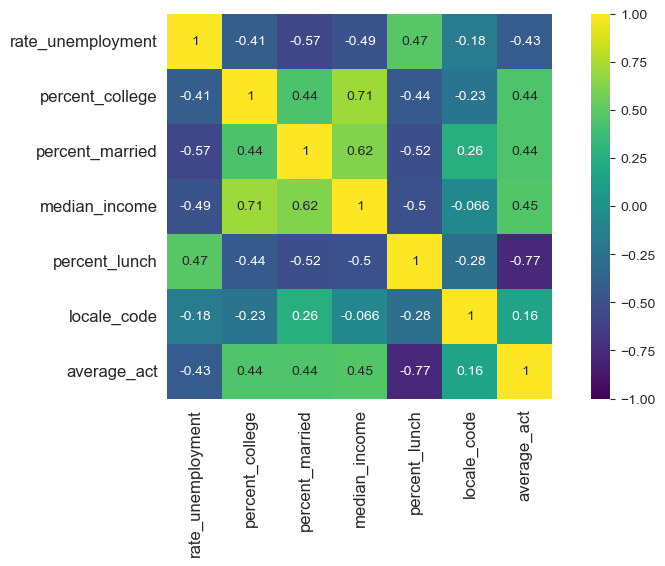

In [265]:
# Define Predictor Variables 
# Make sure localce_code is not in these
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch', 'state', 'charter']

# Keep only the Numerical Predictors
numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

# Build the Correlation Matrix
# Keep locale_code and average_act values out of the predictions
# Use locale_code in this NOT geoassignment since we need numerical values
corr_matrix = df[numerical_predictors + ["locale_code"] + ["average_act"]].corr()

# Plot the results as a Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap="viridis"
)

plt.tick_params(labelsize=12)

plt.show()

**Summary:** In the above code we aimed to plot the correlation matrix of the numerical variables in the training data to explore relationships between them. 

This created a color gride (heatmap) where each square represents **one pair of variables**. <br>
The colors show the **strength and direction** of each correlantion between the variables: 

- Yellow and Green -- represent a strong positive relationship
- Dark Purple -- represent a strong negative relationship
- Blue and Green -- represent little to no relationship


**Analysis:** We can see here that ACT/SAT exam score (`average_act`) has a:

- **positive relationship** with percent of college education (`percent_college`), percent of married-couple families (`percent_married`), and median income (`median_income`). 

- **negatve relationship** with unemployment rate (`rate_unemployment`) and percent of students that qualify for free lunch programs (`school_lunch`).

- **little to no relationship** with the goegraphical location of a school (`locale_code`)... 


As a reminder, the labeling conventions follow these rules:
- **City** --> 11, 12, 13 
- **Suburban** --> 21, 22, 23
- **Town** --> 31, 32, 33 
- **Rural** --> 41, 42, 43

So just becuase there **appears** to be no relationship between exam scores and a schools geoaasingment, this does NOT MEAN this is a fact.. If you remember, these code values represent assignments. So we may want to look at other visuals to better analyze this relationship in particular.



**Note:** Notice how there is not `geoassignment` variables represented here, this is because the heatmat needs numerical values to display the relationships. We can analyze these trends between `geoassignment` by looking at the `locale_code` instead.



#### Pair Plot

Now we want to display the relationships between the variables in a differnt plotting method. 

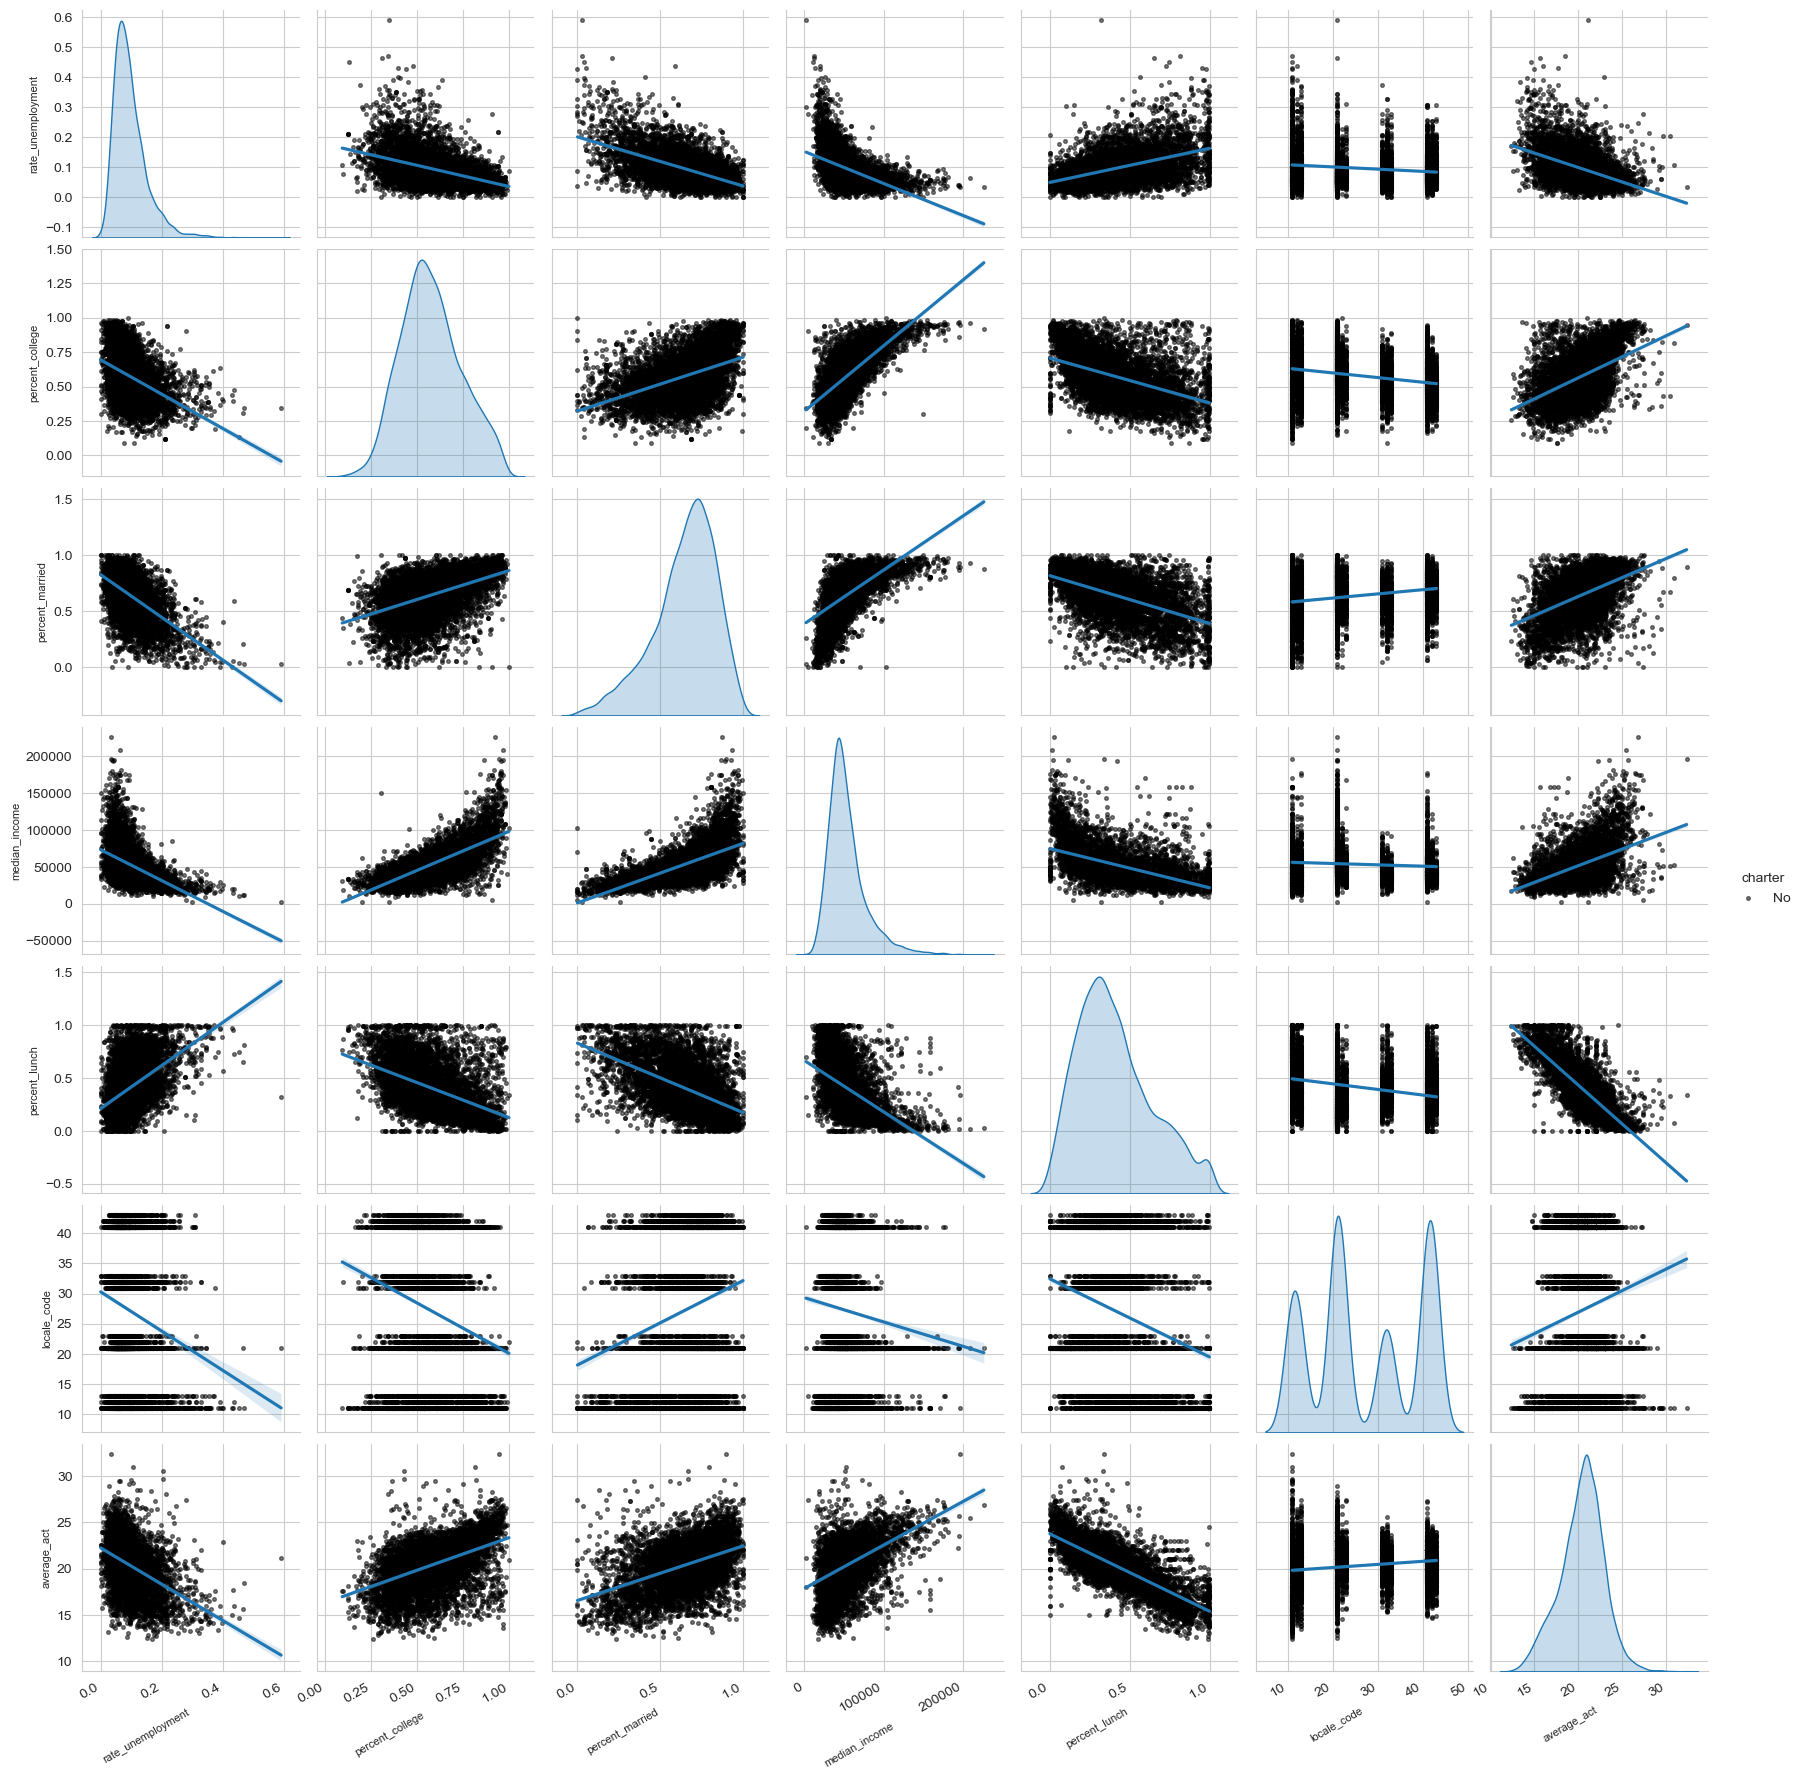

In [104]:
fig = sns.pairplot(
    data=df,
    vars=numerical_predictors + ['locale_code'] + ['average_act'],
    hue='charter',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

**Summary:** By choosing to display the relationships between the variable in a pair plot, we are able to gain an alternative perctive on the direction these relationships trend. The additonal regression line helps put an emphasis on what direction the relationship is trending. The conclusions we draw from these pair plots will be used verify how accurate our finding in the heatmap were.

Based off of the plots above, we can observe that average ACT/SAT scores seem to have a **positively trending relationship** with the same variables we identified in the heatmap -- `percent_college`, `percent_married`, and `median_income`.
And the same **negatively trending relationship** with the variables also identified in the heatmap -- `percent_lunch` and `rate_unemployment`.

### Identifying Outliers

In order to verify if our findings are true, we will use the interquartile range to identify outliers. <br>
These outliers can also be displayed in **boxplots** of the data. 

Median income is on a very different scale than the other predictors, so we will make two plots to explore the data.

**Plot 1**

Show outlies in the variables defined as our Numerical Predictors

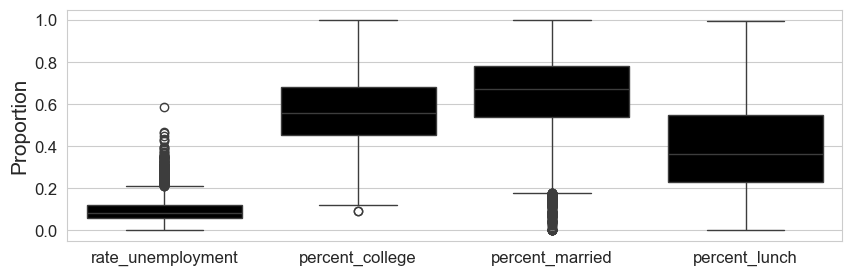

In [105]:
plt.figure(figsize=(10,3))

fractions = list(numerical_predictors)
fractions.remove('median_income')

sns.boxplot(data=df[fractions], color='k')

plt.ylabel('Proportion', fontsize=15)

plt.tick_params(labelsize=12)

plt.show()

**Plot 2**

Shows outliers in just the Median Income

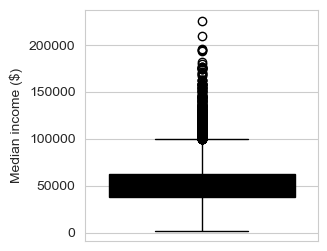

In [106]:
plt.figure(figsize=(3,3))

sns.boxplot(data=df, y='median_income', color='k')

plt.ylabel('Median income ($)')

plt.show()

**Summary:** Based off of the plots displayed above, there appears to be outliers in `rate_unemployment`, `percent_college`, `percent_married` and `median_income`. <br>
It is importatnt to note that these outliers do not represent an obviously incorrect values... they most likely **reflect skewed distributions**. 

Based off of this finding, we may consider applying something like a **log transformation** to these predictors as we explore different models.

### Analyzing `average_act` and `geoassingnment` relationship

We want to output visuals that can display the relationship between school performance and geographical assignment. <br>
In order to do this, we will use the extra variable we created that displays the actual names of each geoassignment category in these visuals.

#### Amount of schools in each `geoassignment`

In [109]:
print(df['geoassignment'].value_counts(dropna=False))

geoassignment
Suburban    2159
Rural       2157
City        1487
Town        1046
Name: count, dtype: int64


<br>

#### What is the `average_act` exam scores for each `geoassignment`?

In [165]:
#print("Average ACT/SAT per school assigment:")
df[['geoassignment', 'average_act']].groupby('geoassignment').mean()

,average_act
geoassignment,
City,18.836521
Rural,20.444302
Suburban,21.016287
Town,20.323447


#### Boxplot 

/var/folders/z2/g11yqhsj1k71fwt1tzjpqgp80000gn/T/ipykernel_46840/2987947058.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




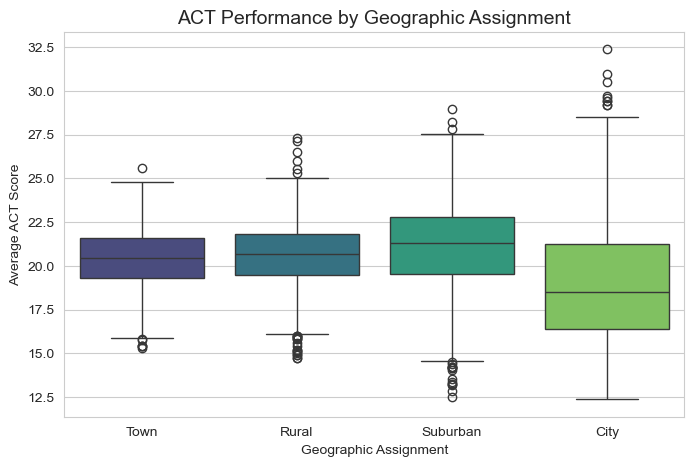

In [108]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='geoassignment', y='average_act', palette='viridis')
plt.title('ACT Performance by Geographic Assignment', fontsize=14)
plt.xlabel('Geographic Assignment')
plt.ylabel('Average ACT Score')
plt.show()


**Summary:** The boxplots above shows us quite a few beneficial details in supplementing our analysis. We can see the quartiles of exam scores for each geoassignment category in addition to the **range of exam scores** in each geoassignment category. 

For example, we can see that there is a smaller range in ACT/SAT exam scores for schools that are in **Towns** compared to those that are in a **City**. 

In addition to this, we can see that each boxplot has a different color... This comes from the heatmap coloring that we displayed prior: 

- Yellow and Green -- represent a strong positive relationship
- Dark Purple -- represent a strong negative relationship
- Blue and Green -- represent little to no relationship

Based off of these findings together, we can observe that schools that have geoassignments of **City** have a **strong positive relationship** with ACT/SAT exam scores. While schools that have a geoassignment of **Town** have a **strong negative relationship** with ACT/SAT exam scores.

But one thing to note based off of this display alone -- Although schools with a geoassignment classification of a City seem to have a more positive relationship... we can also see that these same schools have **lower exam scores** in this data compared to the other categories. <br>
This can be based off of a couple of different factors, most likely this is telling us that there is a wider range of exam scores because the student population in these scools in larger.

<br>

## Communicating the Results

**Problem Statement:** Does school geoassignment have a strong effect on school performance?

#### Approach

In order to answer our original question, we analyzed the relationship of average ACT/SAT exam scores accross multiple socioeconomic variables. By having multiple relationships to compare across, we were able to not only determine whether or not a schools geoassignment classification has an effect on school performance, but also measure **the level** in which this occurs. 

This additional detail helped us answer the part of our question that asks if a schools geoassingment classifications has a **"strong effect"** on school performance. We determined this by analyzing whether or not school geoassignment has a **positive or negative relationship** with school performance. 

In addition to this, we also exectuted an additional step to dispaly the classification names associated with these locale code values, allowing us to see what each classification was representing -- Suburban, Rural, Town, or City.

#### Comparing School Performance Across Variables

When analyzing the effect that each socioeconomic variable had on school performance, we were able to conclude that ACT/SAT exam scores have a **positive relationship** with college education, married-couple families, and median income... a **negative relationship** with unemployment rate and qualification for free lunch programs ... and **little to no relationship** with the geographical assignment of the school.

#### Comparing School Performance Across Geographical Assignments

When analyzing the relationships between all four geoassignment categories and school performance, we were able to determine that students that attend a school in a **Suburban** area score, on average, approximitaly **6% higher** than students that attend a school in a City, **2% higher** than students that attend a school in Town, and **1.5% higher** than students that attend a school in a Rural area. 

#### Answering the Problem Statement

Based off of the differing average exam scores for each geoassignment category, it is safe to assume that a schools geographical assignment **does** have an affect on school performance. But based off how little these averages differ, we cannot confidently support that geoassignment necessarily has a **strong** affect on school performance.

When analyzing the relationship of school performace and all socioeconmic variables, it appears that there are **other school variables that have stronger effects on school performace** than geographical assignment. Specifically - percentage of college education, percentage of students from married-couple families, and median income.